<h1><center> Chapitre I :</center></h1>
<h1><center> Classification Binaire<br><i>- Sentiment Analysis -</i></center></h1>
<hr>

## Motivation et Objectifs


Dans ce premier chapitre, on se servira d'un problème d'analyse de sentiments pour présenter les différentes méthodes de classification binaire en machine learning. Concrètement, par "analyse de sentiments" on entend réussir à associer une opinion (ici, positive ou négative) à un avis sous forme textuelle. 

En termes plus formels, il s'agit d'apprendre une fonction $f_\theta : \mathcal{X} \to \mathcal{Y}$, où $\mathcal{X}$ désigne l'espace des textes et $\mathcal{Y} = \{0, 1\}$ l'ensemble des deux classes possibles.

Si nous avons choisi de commencer par un problème d’analyse de sentiments plutôt que par un jeu de données plus simple, c'est pour profiter de ce chapitre pour illustrer une difficulté majeure en apprentissage automatique : les données brutes (ici, des séquences de caractères) ne sont pas directement exploitables par des modèles numériques. Une partie du travail consistera donc à comprendre comment transformer un texte en une représentation pertinente, avant de s'intéresser à la classification.

Nous comparerons ensuite plusieurs approches de classification (SVM, Régression Logistique, Naive Bayes) ainsi que plusieurs stratégies de vectorisation du texte (CountVectorizer, TF-IDF), afin de comprendre les forces et les limites de chacune.

Ce chapitre se découpera ainsi en six sections :

1. La **formalisation du problème** de classification et la représentation vectorielle du texte
2. La présentation des **Pipelines Scikit-learn** pour la construction de nos modèles
3. Le **Support Vector Machine (SVM)** : séparation par hyperplan et maximisation de la marge
4. La **Régression Logistique** : classification probabiliste par maximum de vraisemblance
5. Le **Naive Bayes** : une première approche générative de la classification
6. L'**analyse comparative** des méthodes et les **pistes d'amélioration**

## Présentation du Corpus

Les modèles étudiés dans ce projet s’entraîneront sur un corpus d’environ 40 000 avis clients en anglais portant sur des hôtels. Ce dataset, disponible (comme tous les datasets que nous utiliserons) dans le dossier `data/`, est parfaitement exploitable pour un usage en **apprentissage supervisé**, puisque chaque avis est déjà associé à une étiquette indiquant si le client est satisfait ou non. 

#### Importation des bibliothèques

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np
import time

# Prétraitement
from sklearn.preprocessing import LabelEncoder
import nltk
import string
import re

# Vectorisation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Modèles de classification
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Outils d'évaluation et optimisation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Configuration de l'affichage
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#### Chargement du dataset

In [2]:
import os

path = os.path.join("data", "sentiment-analysis", "train.csv")
df = pd.read_csv(path)
print(f"Dataset initial : {df.shape[0]} avis")

# Suppression des doublons
df = df.drop_duplicates(keep='first')
print(f"Après suppression des doublons : {df.shape[0]} avis")

# Encodage des labels : 0 (satisfait) / 1 (insatisfait)
encoder = LabelEncoder()
df['Is_Response'] = encoder.fit_transform(df['Is_Response'])

# Analyse de la longueur des avis
df['word_count'] = df['Description'].str.split().str.len()
print(f"\nLongueur moyenne des avis : {df['word_count'].mean():.1f} mots")
print(f"Longueur médiane : {df['word_count'].median():.0f} mots")

# Suppression des colonnes non pertinentes
df.drop(columns=['User_ID', 'Browser_Used', 'Device_Used'], inplace=True)

print(f"\nDistribution des classes :")
for label, count in df['Is_Response'].value_counts().items():
    percentage = (count / len(df)) * 100
    label_name = "Satisfait" if label == 0 else "Insatisfait"
    print(f"  Classe {label} ({label_name}): {count} avis ({percentage:.1f}%)")
print("\n")
df.head()

Dataset initial : 38932 avis
Après suppression des doublons : 38932 avis

Longueur moyenne des avis : 157.3 mots
Longueur médiane : 123 mots

Distribution des classes :
  Classe 0 (Satisfait): 26521 avis (68.1%)
  Classe 1 (Insatisfait): 12411 avis (31.9%)




,Description,Is_Response,word_count
0,The room was kind of clean but had a VERY stro...,1,46
1,I stayed at the Crown Plaza April -- - April -...,1,208
2,I booked this hotel through Hotwire at the low...,1,232
3,Stayed here with husband and sons on the way t...,0,93
4,My girlfriends and I stayed here to celebrate ...,1,297


On peut dors et déjà remarquer que la distribution des classes n'est pas vraiment équilibrée dans ce dataset (68.1%/31.9%), ce qui constitue un biais pour tout entrainement que l'on réalisera. En effet, de par ce déséquilibre, un modèle entrainé sur ce dataset aura naturellement une probabilité plus imortante de prédire la classe dominante. C'est pourquoi, on adaptera notre approche en privilégiant notament le F1-score à l'Accuracy pour la comparaison des méthodes (voir II.2.2. sur les métriques de score).

#### Séparation Train/Test

Avant d'entraîner un modèle, il est nécessaire de partitionner les données disponibles en un **ensemble d'entraînement** (*train set*) et un **ensemble de test** (*test set*).

En effet, un modèle de machine learning apprend en ajustant ses paramètres pour reproduire correctement les étiquettes des exemples qu'il voit pendant l'entraînement. Ainsi, si on évaluait ensuite les capacités du modèle sur les mêmes données, on mesurerait simplement sa capacité à *mémoriser* les exemples, et non sa capacité à *généraliser* à de nouveaux cas.

Un modèle qui performe très bien sur le train set mais échoue sur de nouvelles données est dit **en sur-apprentissage** (*overfitting*). À l'opposé, un modèle trop simple qui ne capture pas la structure des données est dit **en sous-apprentissage** (*underfitting*). La qualité réelle d'un modèle est donc sa capacité à généraliser, que l'on estime en réservant une portion des données (que le modèle ne verra *jamais* pendant l'entraînement) pour l'évaluation finale.

**Note** : On utilise l'option `stratify` de la fonction `train_test_split` de scikit-learn afin de garantir que la proportion de chaque classe est préservée dans le train set et dans le test set.

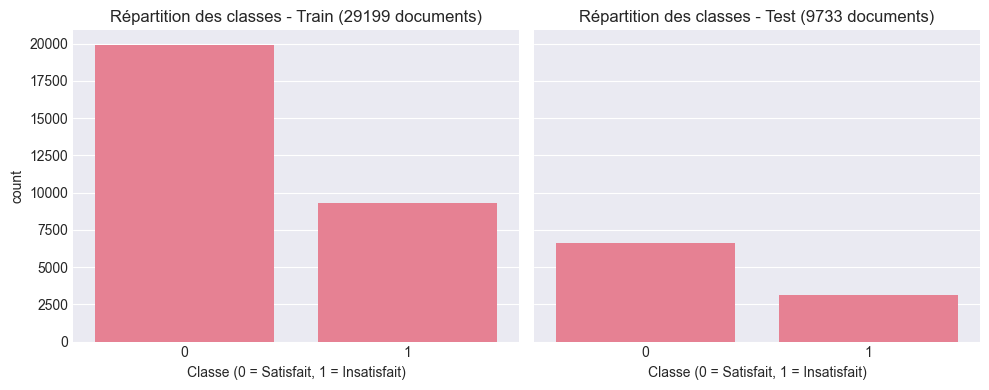

In [3]:
x = df['Description']
y = df['Is_Response']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.25, 
    random_state=100,
    stratify=y  # Garantit la même proportion de classes dans train et test
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title(f"Répartition des classes - Train ({x_train.shape[0]} documents)")
axes[0].set_xlabel("Classe (0 = Satisfait, 1 = Insatisfait)")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title(f"Répartition des classes - Test ({x_test.shape[0]} documents)")
axes[1].set_xlabel("Classe (0 = Satisfait, 1 = Insatisfait)")

plt.tight_layout()
plt.show()

## I. Formalisation du problème

### I.1. Apprentissage supervisé et classification binaire

#### I.1.1. Le cadre général de l'apprentissage supervisé

L'objectif de l'apprentissage supervisé est d'apprendre une règle de prédiction à partir d'un ensemble d'exemples étiquetés. 

Formellement, on dispose d'un corpus d'entraînement $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$, où chaque $\mathbf{x}_i \in \mathcal{X}$ est une observation et $y_i \in \mathcal{Y}$ son étiquette. L'objectif est d'apprendre une fonction $f_\theta : \mathcal{X} \to \mathcal{Y}$, paramétrée par $\theta$, qui généralise correctement au-delà des données d'entraînement.

Dans notre cas, $\mathcal{X}$ est l'espace des textes et $\mathcal{Y} = \{0, 1\}$ (satisfait ou insatisfait). 

**Remarque** : Si l'on sépare les méthodes de classification entre binaire et multiclasse ($|\mathcal{Y}| \gt 2$), c'est parce que toutes les méthodes ne prennent pas en compte naturellement le multiclasse. En effet, les modèles comme la SVM et la Logistic Regression sont, à des degrés différents, intrinsèquement binaire. On devra donc utiliser des méthodes d'extensions de ces modèles pour le multiclasse dans le chapitre suivant.

L'objectif défini ci-dessus peut ainsi se formaliser naturellement en termes probabilistes. On cherchera alors à modéliser la **distribution conditionnelle** $p_\theta(y \mid \mathbf{x})$, c'est-à-dire la probabilité que l'étiquette soit $y$, sachant l'observation $\mathbf{x}$. La règle de décision associée est alors :

$$\hat{y} = \arg\max_{y \in \mathcal{Y}}\; p_\theta(y \mid \mathbf{x})$$

La question qui détermine la nature du modèle à implémenter, est donc : comment modéliser $p_\theta(y \mid \mathbf{x})$ ?

#### I.1.2. Trois familles d'approches

Les modèles que nous allons étudier dans ce chapitre peuvent se répartir dans trois familles de conception :

* **Les modèles discriminants géométriques** (comme le *Support Vector Machine*) qui ne modélisent pas $p_\theta(y \mid \mathbf{x})$ de façon explicite. Ils cherchent directement une **frontière de décision** dans $\mathcal{X}$ qui sépare les deux classes aussi nettement que possible. L'étiquette est ensuite déduite en regardant de quel côté de cette frontière se trouve l'observation $\mathbf{x}$. Ces modèles sont robustes et efficaces en haute dimension, mais ne produisent pas naturellement de probabilités.

* **Les modèles discriminants probabilistes** (comme la *Régression Logistique*) qui modélisent $p_\theta(y \mid \mathbf{x})$ directement, en supposant que cette probabilité suit une forme paramétrique particulière (la fonction sigmoïde). L'entraînement revient à maximiser la vraisemblance des étiquettes observées. Ces modèles produisent donc des probabilités interprétables et s'adaptent généralement mieux aux jeux de données déséquilibrés.

* **Les modèles génératifs** (comme le *Naive Bayes*) qui adoptent une perspective différente, puisqu'ils modélisent la distribution jointe $p(\mathbf{x}, y) = p(\mathbf{x} \mid y)\, p(y)$, puis en déduisent $p(y \mid \mathbf{x})$ via le théorème de Bayes. Dans ce cas, on ne cherche donc plus seulement à séparer les classes, mais à comprendre *comment chaque classe génère les données*. Cette distinction entre modèles discriminants et génératifs deviendra centrale dans le chapitre IV, où les modèles génératifs seront utilisés non plus pour classer, mais pour produire de nouvelles données.

On étudiera ces trois approches successivement, avant de comparer leurs performances sur le même jeu de données dans la section VI.

### I.2. Représentation vectorielle du corpus : Le Modèle Bag-of-Words

#### I.2.1. Problématique

Les algorithmes de **machine learning** ne peuvent donc traiter que des vecteurs numériques $\mathbf{x}\in\mathbb{R}^d$, alors que les données que nous devons traiter sont des séquences de caractères. Il est donc nécessaire de définir une transformation $\phi$ qui projette chaque document vers un espace vectoriel de dimension $d$ :

$$\text{Texte} \xrightarrow{\phi} \mathbb{R}^d$$

Le défi est que cette transformation doit préserver, autant que possible, l’information utile pour la tâche de classification à réaliser, tout en produisant des vecteurs exploitables par des modèles numériques. 

#### I.2.2. Principe du Bag‑of‑Words

Le modèle **Bag‑of‑Words (BoW)** représente chaque document par le nombre d'occurences (ou la fréquence) des termes qu’il contient, sans tenir compte de l’ordre des mots. Cette méthode permet de garder une représentation simple et interprétable, et constitue aujourd'hui la base de nombreuses méthodes classiques de traitement du langage.

##### I.2.2.a CountVectorizer Construction de la Matrice Terme‑Document

Depuis un corpus $\mathcal{D}=\{d_1,\dots,d_n\}$ et un vocabulaire $V=\{w_1,\dots,w_{|V|}\}$ extrait du corpus, le **CountVectorizer** construit une matrice terme‑document $X\in\mathbb{N}^{n\times|V|}$ telle que :

$$
X_{ij}=\text{nombre d'occurrences du mot } w_j \text{ dans } d_i.
$$

Par exemple, si on souhaite encoder la matrice terme-document du corpus suivant :

* $d_1$ : "hotel propre service excellent" 
* $d_2$ : "service moyen hotel sale"  
* $d_3$ : "excellent hotel propre"   

On commence par définir son vocabulaire associé : $V = \{\text{hotel, propre, service, excellent, moyen, sale}\}$

Puis on regroupe le nombre d'occurence de chaque terme pour chaque document dans la matrice :

$$X = \begin{pmatrix}
1 & 1 & 1 & 1 & 0 & 0 \\
1 & 0 & 1 & 0 & 1 & 1 \\
1 & 1 & 0 & 1 & 0 & 0
\end{pmatrix}, \quad \text{ tel que } x_i \in \mathbb{R}^{|V|}$$

A noter qu'ici, l'exemple n'est pas représentatif d'une matrice terme-document construite à partir d'un vrai corpus. En effet, cette matrice est généralement **creuse** (*sparse*) dans le sens où la plupart des composantes sont nulles car chaque document n’utilise qu’une fraction du vocabulaire total. 

**Remarque** : Contrairement aux méthodes utilisées par les modèles *Transformers* utilisés par les LLM, le modèle Bag‑of‑Words **ignore totalement l’ordre des mots** et les relations syntaxiques ; il ne retient que la présence et la fréquence des termes. 

##### I.2.2.b Limitation du CountVectorizer Vers le TF‑IDF

Le problème du CountVectorizer est qu'il donne le même poids à tous les termes, alors que certains mots très fréquents sont souvent génériques et donc peu discriminants. Le **TF‑IDF** corrige cela en pondérant la fréquence d’un terme dans un document par l’inverse de sa fréquence dans le corpus :

$$\text{TF-IDF}(w,d)=\text{TF}(w,d)\times\text{IDF}(w),$$

Avec par exemple :

$$\text{TF}(w,d)=\frac{\text{count}(w,d)}{\sum_{w'}\text{count}(w',d)},\qquad
\text{IDF}(w)=\log\frac{n}{\text{df}(w)},$$

où $\text{df}(w)$ est le nombre de documents contenant $w$. 

Ainsi, un terme présent dans tous les documents aura une importance de $\text{IDF}=0$ et n’influencera pas la représentation, tandis qu’un terme rare verra son poids augmenter. De cette manière, la pondération **TF‑IDF** permet de réduire l’impact des mots fréquents et de mettre en valeur les termes discriminants. 


#### I.2.3. Prétraitement du Texte

Avant d’extraire le vocabulaire et de construire $X$, il est nécessaire de **prétraiter** le texte afin de réduire le bruit et la variabilité orthographique.

##### I.2.3.a. Etapes de prétraitement du texte

Les étapes les plus courantes de prétraitement sont généralement : 
- la **Tokenisation** : découpage en tokens (mots, nombres, ponctuation).  
- le **Nettoyage** : mise en minuscules, suppression de la ponctuation et des caractères spéciaux.  
- la **Suppression des stopwords** (mots très fréquents peu informatifs). 

Ensuite, on peut potentiellement ajouter une **Racinisation/Lemmatisation** (*Stemming/Lemmatization*) du texte. Autrement dit, on peut vouloir **regrouper sous une même forme les occurrences lexicales équivalentes** afin de réduire la sparsité des représentations textuelles. Cela permet au modèle d’apprendre sur des unités plus stables et plus générales, plutôt que sur chaque flexion d'une même unité de sens, au détriment d'une perte d'information plus ou moins importante.

##### I.2.3.b. Regrouper les occurrences lexicales équivalentes : *Stemming* et *Lemmatization*

##### **Racinisation** (*Stemming*)

La **racinisation** consiste à réduire un mot à une forme tronquée appelée *stem*, obtenue en appliquant un ensemble de **règles heuristiques** visant à supprimer les suffixes les plus fréquents. L'objectif est de regrouper les variations d'un mot en leur radical ou racine ("courait", "coureur" $\rightarrow$ "cour")

Concrètement, les algorithmes de stemming (comme *Porter* ou *Snowball*) utilisent des **règles simples** et purement **basées sur la morphologie** des mots. Par exemple, on peut notament citer les règles :  
* supprimer les marques de pluriel ou de genre (`-s`, `-es`, `-ent`),  
* supprimer les terminaisons verbales (`-ait`, `-aient`, `-era`, `-eront`, etc.),  
* réduire les suffixes dérivationnels (`-ment`, `-tion`, `-able`, etc.),  
* normaliser les pluriels orthographiques (`-aux` $\rightarrow$ `-al`, `-eaux` $\rightarrow$ `-eau`).  

Les algorithmes appliquent donc ces règles **sans analyse grammaticale ni sémantique**, ce qui rend la méthode rapide et efficace, mais parfois trop approximative. En effet, le radical obtenu n’est pas toujours un mot existant, et certains mots pourtant distincts peuvent être ramenés à la même racine ("courait", "cours" $\rightarrow$ "cour"). 

Le stemming est donc une méthode simple et peu coûteuse, mais qui se limite plutôt aux tâches où la précision linguistique n’est pas essentielle.

##### **Lemmatisation**

La **lemmatisation** vise à ramener un mot à sa **forme canonique** (le *lemme*), telle qu’elle apparaît dans un dictionnaire. Par exemple, “couraient”, “couru” et “courirons” sont tous ramenés à *courir*. Par contre "coureur" reste "coureur" puisqu'il n'appartient pas à la même catégorie grammaticale (verbe/nom). 

Contrairement au stemming, la lemmatisation repose donc sur une **analyse linguistique complète**, mobilisant :  
* des **ressources morphologiques** (lexiques, tables de conjugaison),  
* des **règles grammaticales** (catégorie du mot, genre, nombre, temps, mode),  
* parfois une **analyse syntaxique** pour lever les ambiguïtés.  

Cette approche permet ainsi d’obtenir un vocabulaire correct et cohérent d'un point de vue linguistique, ce qui améliore la qualité des représentations textuelles et évite les erreurs de regroupement de termes distincts. Néanmoins, ce travail d'analyse linguistique est bien plus coûteux en calcul que la méthode de stemming et dépend notament de la qualité des données pour la langue considérée.

**Note** : Les classes *CountVectorizer* et *TfidfVectorizer* de *scikit-learn* intègrent déjà les opérations élémentaires pour le prétraitement de texte (mise en minuscules, tokenisation, suppression de la ponctuation et retrait éventuel des stopwords). En revanche, elles n’effectuent pas la racinisation/lemmatisation, qui doivent être appliqués séparément. Dans la suite, on entrainera donc nos modèles sans effectuer de racinisation. On n'introduira cette technique qu'en fin de chapitre, pour montrer les potentielles améliorations apportées. On utilisera à ce moment la bibliothèque *NLTK* de Python, qui propose plusieurs algorithmes de racinisation ; en particulier le *SnowballStemmer*, l'algorithme le plus stable et le plus couramment utilisé pour de l'anglais.


### I.3. Enchaîner les étapes de traitement : introduction des *Pipelines* Scikit‑learn

Maintenant que nos données sont représentées sous forme de vecteurs numériques, on doit désormais définir une méthode pour enchaîner proprement la vectorisation et l’apprentissage, afin de garantir que chaque transformation soit appliquée au bon moment et sur les bonnes données.

Pour ce faire, on utilise donc des objets appelés **Pipelines**, que l'on récupère dans le framework *Scikit‑learn*. Ces objets permettent d'implémenter facilement des méthodes d'apprentissage automatique tout en garantissant l'absence de tout **data leakage**, qui fausserait l’évaluation. 

Par exemple, ils permettent d'éviter de faire des erreurs basiques, comme vectoriser tout le corpus d’un seul bloc, puis de découper la matrice obtenue en un ensemble d’entraînement et un ensemble de test, ce qui construirait le vocabulaire à partir de tout l’ensemble des données, y compris celles censées rester inconnues du modèle pendant l’entraînement.  

Au contraire, un pipeline imposera le déroulement suivant pour le traitement des données :
* le vocabulaire est appris **uniquement** à partir des données d’entraînement ;
* les données de test sont transformées avec ce même vocabulaire, comme en situation réelle ;
* l’ensemble vectorisation + classification est traité comme un seul modèle, cohérent et reproductible.

#### I.3.1. Structure d’un pipeline Scikit‑learn

Le constructeur de pipeline ne prend en paramètre qu'une liste de tuples représentant une séquence d’étapes à appliquer dans l’ordre. 

Dans notre cas, chaque Pipeline sera donc construit selon :
```python
Pipeline([
    ('vectorizer', CountVectorizer()),  # Texte -> vecteurs
    ('classifier', SVC())               # Vecteurs -> classes
])
```

#### I.3.2. Fonctionnement : entraînement et prédiction

Ainsi, l'avantage du pipeline est que, peu importe la séquence d'actions qu'il contient, il conserve une structure commune pour tous les modèles. De cette manière, on pourra entrainer n'importe quel modèle que l'on souhaite implémenter à l'aide de la même méthode `fit` de la classe Pipeliner.

Concrètement, comme tous nos pipelines sont constitués d'un `'vectorizer'` et d'un `'classifier'`, cette phase d'entrainera sera composée de :
1. `vectorizer.fit(x_train)` : construction du vocabulaire à partir des textes d’entraînement.  
2. `vectorizer.transform(x_train)` : projection des textes en matrice  
   \(X \in \mathbb{N}^{n \times |V|}\).  
3. `classifier.fit(X, y_train)` : apprentissage du modèle sur les vecteurs.

On pourra ensuite utiliser la fonction `predict` sur nos modèles, qui calcule :
1. `vectorizer.transform(x_test)` : projection des textes de test avec le **même** vocabulaire.  
2. `classifier.predict(...)` : prédiction des classes.


#### I.3.3. Avantages du Pipeline

La structure préimplémentée des Pipelines Scikit‑learn apporte plusieurs avantages, pour mener des expériences fiables et construire des modèles réellement utilisables.

En effet, les pipelines s’intègrent naturellement aux outils d’optimisation de Scikit‑learn, comme `GridSearchCV` ou `RandomizedSearchCV`, ce qui permet de tester différents vectoriseurs et classifieurs, et d’ajuster leurs hyperparamètres dans un même espace de recherche.

De plus, les pipelines ont l'avantage de pouvoir être sérialisés (via `pickle` ou `joblib`) et rechargés tels quels dans un script ou une API, ce qui facilite le déploiement d’un modèle au complet (vectorisation incluse).

## II. Support Vector Machine (SVM)

Maintenant que le problème de classification binaire a été formellement défini, et que le texte a été vectorisé, on peut s'intéresser au premier modèle de classification : le *Support Vector Machine* (SVM). Introduit par Cortes et Vapnik en 1995, il reste aujourd'hui l'un des algorithmes de référence pour la classification de texte en haute dimension.

Concrètement, l'objectif du SVM est de séparer les deux classes par une **frontière de décision linéaire** dans l'espace des représentations vectorielles, en choisissant parmi toutes les frontières possibles celle qui offre le plus grand écart avec les données des deux classes ; autrement dit, celle qui **maximise la marge**.

### II.1. Hyperplan séparateur et marge

#### II.1.1. L'hyperplan de décision

Dans $\mathbb{R}^d$, un **hyperplan** est défini par l'équation :

$$\mathcal{H} : \mathbf{w}^T \mathbf{x} + b = 0$$

où $\mathbf{w} \in \mathbb{R}^d$ est le vecteur normal à l'hyperplan et $b \in \mathbb{R}$ le biais qui contrôle son décalage par rapport à l'origine. En dimension 2 c'est une droite, en dimension 3 c'est un plan, et en dimension $d$ quelconque, c'est un sous-espace affine de dimension $d-1$.

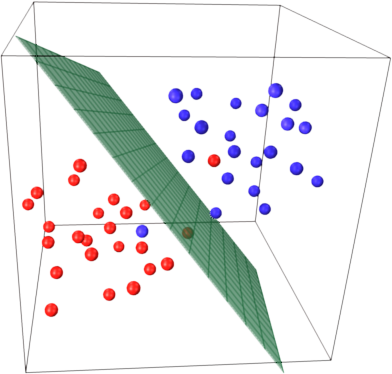

La règle de décision associée à la SVM est donc :

$$f(\mathbf{x}) = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

Un point $\mathbf{x}$ est ainsi classé **+1** si $\mathbf{w}^T \mathbf{x} + b > 0$, et **-1** sinon.

#### II.1.2. Maximiser la marge

Si, pour un jeu de données linéairement séparable, une infinité d'hyperplans peuvent séparer parfaitement les données d'entraînement, l'objectif de la SVM est de trouver **celui qui maximise la marge**, c'est-à-dire la distance minimale entre l'hyperplan et les points d'entraînement.

En effet, la théorie de l'apprentissage statistique (*Vapnik, 1995*) démontre qu'un classificateur avec une grande marge généralise mieux. Intuitivement, on peut voir cette marge comme une "zone tampon" qui rend le modèle robuste aux petites perturbations.


#### II.1.3. Calcul de la marge : SVM à marge dure

Pour lever l'ambiguïté due à l'invariance d'échelle (multiplier $\mathbf{w}$ et $b$ par une constante ne change pas l'hyperplan), on impose donc une convention de normalisation sur $\mathbf{w}$ et $b$, telle que les points $(x^*, y^*)$ **les plus proches de l’hyperplan** satisfassent : $y^*(\mathbf{w}^T\mathbf{x}^*+b)=1$

Ces points sont appelés les **vecteurs de support** ; ce sont eux qui définissent les hyperplans de marge :

$$\mathcal{H}_+ : \mathbf{w}^T \mathbf{x} + b = +1 \qquad \text{et} \qquad
\mathcal{H}_- : \mathbf{w}^T \mathbf{x} + b = -1$$

De cette manière, sachant que la distance d'un point $\mathbf{x}_i$ à l'hyperplan $\mathcal{H}$ est défini par :
$$d(\mathbf{x}_i, \mathcal{H}) = \frac{|\mathbf{w}^T \mathbf{x}_i + b|}{\|\mathbf{w}\|} = \frac{y_i(\mathbf{w}^T \mathbf{x}_i + b)}{\|\mathbf{w}\|}, \quad \text{car }\left\{ \begin{array}{cl}
\mathbf{w}^T \mathbf{x}_i + b \ge 1 & \text{et} & y_i=+1
\\
\mathbf{w}^T \mathbf{x}_i + b \le  -1 & \text{et} & y_i=-1
\end{array} \right.$$

On peut trouver la marge totale à maximiser en prenant la distance entre les deux hyperplans :

$$\text{Marge} = \frac{|\mathbf{w}^T \mathbf{x}^+ + b - \mathbf{w}^T \mathbf{x}^- + b|}{\|\mathbf{w}\|} = \frac{1 - (-1)}{\|\mathbf{w}\|} = \frac{2}{\|\mathbf{w}\|}$$

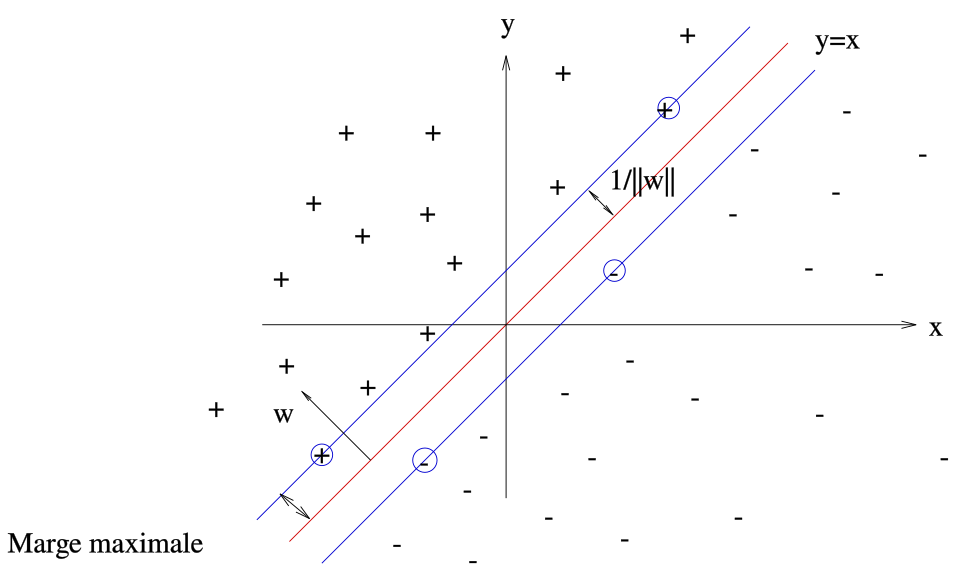

**Maximiser la marge** revient donc à **minimiser $\|\mathbf{w}\|^2$**. 

Si les données sont linéairement séparables (ie. si toutes les contraintes de marge peuvent être satisfaites simultanément), on obtient finalement le problème d'optimisation convexe suivant :

$$\min_{\mathbf{w},\, b} \quad \frac{1}{2} \|\mathbf{w}\|^2 \qquad
\text{tel que} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1, \quad \forall i = 1, \ldots, n$$

Les contraintes imposent ainsi que chaque point soit correctement classé, en restant à au moins une unité normalisée de l'hyperplan décision.

Ce problème primal est l'un des premiers que l'on rencontre en programmation linéaire. Sa structure simples permet aux solveurs modernes d’être extrêmement efficaces sur ce genre de problème, en exploitant la convexité stricte du problème pour garantir une convergence rapide et robuste, même sur des jeux de données de grande dimension.

**Remarque - Vecteurs de support :** La solution optimale $(\mathbf{w}^*, b^*)$ ne dépend que des points situés exactement sur les hyperplans de marge, pour lesquels $y_i(\mathbf{w}^T \mathbf{x}_i + b) = 1$. Les autres points peuvent être retirés du corpus d'entraînement sans modifier la solution.

Le problème est qu'en pratique, les données textuelles ne sont **jamais linéairement séparables** : un même mot peut apparaître dans des avis de sentiments opposés, rendant toute séparation parfaite impossible. La marge dure constitue donc plutôt un cas limite théorique dont la généralisation pratique est la SVM à marge souple.


### II.2. Assouplir la marge : SVM à marge souple 

#### II.2.1. Variables de relaxation et paramètre $C$

La solution de Cortes et Vapnik consiste à **assouplir** les contraintes de marge, en autorisant chaque point à "violer" légèrement la contrainte $y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1$, à condition de payer une pénalité proportionnelle à l'infraction.

Pour cela, on introduit des **variables de relaxation** (*slack variables*) $\xi_i \geq 0$ telles que :

$$\min_{\mathbf{w},\, b,\, \boldsymbol{\xi}} \quad \frac{1}{2} \|\mathbf{w}\|^2
+ C \sum_{i=1}^n \xi_i \qquad
\text{tel que} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

La valeur de $\xi_i$ indique où se trouve le point $\mathbf{x}_i$ par rapport à la marge, soit :
* $\xi_i = 0$ si le point correctement est classé avec marge complète
* $0 < \xi_i < 1$ si le point est correctement classé mais dans la marge (entre $\mathcal{H}$ et $\mathcal{H}_{\pm}$)
* $\xi_i = 1$ si le point est exactement sur l'hyperplan de décision
* $\xi_i > 1$ si le point est **mal classé** (erreur)

Le paramètre $C > 0$ contrôle le **compromis** entre la **largeur de la marge** et la **tolérance aux erreurs** :

- **$C$ grand** : les violations sont fortement pénalisées $\rightarrow$ marge étroite, modèle qui cherche à tout classer correctement $\implies$ risque de surapprentissage.
- **$C$ petit** : les violations sont tolérées $\rightarrow$ marge plus large, modèle plus régulier $\implies$ risque de sous-apprentissage.

Ce paramètre devra être sélectionné par **validation croisée** (*voir la section VII. Amélioration Possibles*).

#### II.2.2. Formulation duale et vecteurs de support

Pour garantir l'optimalité de la solution de notre problème convexe : $$\min_{\theta}f(\theta) \, \text{sous contraintes}\, g_i(\theta)$$

on utilise le théorème de Karush–Kuhn–Tucker (KKT) convexe :
> *Pour un problème d’optimisation convexe avec contraintes d’inégalité, une solution est optimale si et seulement si elle satisfait un ensemble de conditions appelées conditions KKT.*

Ainsi, en partant du **problème d'optimisation primal** :
$$\begin{aligned}
\min_{\mathbf{w}, b, \boldsymbol{\xi}} \quad & \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i \\
\text{s.t.} \quad & y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \forall i \\
& \xi_i \geq 0, \quad \forall i
\end{aligned}$$

on impose les **conditions KKT** (*Karush-Kuhn-Tucker*) :
* *Stationnarité* : $\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 0, \quad \frac{\partial \mathcal{L}}{\partial b} = 0, \quad \frac{\partial \mathcal{L}}{\partial \xi_i} = 0$
* *Faisabilité primale* : $1 - \xi_i - y_i(\mathbf{w}^\top \mathbf{x}_i + b) \le 0$ et $-\xi_i \le 0$
* *Faisabilité duale* : $\alpha_i \ge 0$ et $\mu_i \ge 0$
* *Complémentarité* : $\alpha_i(1 - \xi_i - y_i(\mathbf{w}^\top \mathbf{x}_i + b)) = 0$ et $\mu_i\xi_i = 0$

**Remarque** : La dernière condition est tout ce qui fait la SVM (*Support Vector* Machine) puisqu'elle impose un coefficient nul ($\alpha_i=0$) à tous les points qui vérifient $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \gt 1 - \xi_i$, c'est-à-dire à tous les points qui ne sont pas sur la marge.

On peut ainsi définir le Lagrangien du problème depuis les multiplicateurs de Lagrange $\alpha_i, \mu_i \geq 0$ pour les contraintes $1 - \xi_i - y_i(\mathbf{w}^\top \mathbf{x}_i + b)\le 0$ et $-\xi_i \le 0$ :
$$\mathcal{L}(\mathbf{w}, b, \boldsymbol{\xi}, \boldsymbol{\alpha}, \boldsymbol{\mu}) = \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^n \xi_i - \sum_{i=1}^n \alpha_i[y_i(\mathbf{w}^T\mathbf{x}_i + b) - 1 + \xi_i] - \sum_{i=1}^n \mu_i \xi_i$$

Dans ce sens, la seule condition qui nous reste à vérifier est la stationnarité :

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 0 \quad \Rightarrow \quad \mathbf{w} = \sum_{i=1}^n \alpha_i y_i \mathbf{x}_i$$

$$\frac{\partial \mathcal{L}}{\partial b} = 0 \quad \Rightarrow \quad \sum_{i=1}^n \alpha_i y_i = 0$$

$$\frac{\partial \mathcal{L}}{\partial \xi_i} = 0 \quad \Rightarrow \quad C - \alpha_i - \mu_i = 0 \quad \Rightarrow \quad 0 \leq \alpha_i \leq C$$

ce qui nous permet d'obtenir le **problème dual** qui garantit de trouver une **solution optimale**, en substituant $\mathbf{w} = \sum_{i=1}^n \alpha_i y_i \mathbf{x}_i$ dans le Lagrangien :
$$\begin{aligned}
\max_{\boldsymbol{\alpha}} \quad & \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j \mathbf{x}_i^T \mathbf{x}_j \\
\text{s.t.} \quad & 0 \leq \alpha_i \leq C, \quad \forall i \\
& \sum_{i=1}^n \alpha_i y_i = 0
\end{aligned}$$

Finalement, la fonction de décision associée s'écrit en fonction des $\alpha_i$ calculés :

$$\boxed{f(\mathbf{x}) = \text{sign}\left(\mathbf{w}^T \mathbf{x} + b\right) = \text{sign}\!\left(\sum_{i=1}^n \alpha_i y_i \,\mathbf{x}_i^T \mathbf{x} + b\right)}$$

On peut remarquer que la prédiction pour un nouveau point $\mathbf{x}$ ne dépend des données d'entraînement qu'à travers des **produits scalaires** $\mathbf{x}_i^T \mathbf{x}$, ce qui permettra de rendre possible le *kernel trick*.

#### II.2.3. Noyaux : classifier dans un espace transformé

Même avec une marge souple, certains problèmes restent intrinsèquement non-linéaires.

Par exemple, pour des données en cercles concentriques :

$$\mathbf{x} = (x_1, x_2) \in \mathbb{R}^2, \quad y = \begin{cases} +1 & \text{si } x_1^2 + x_2^2 > 1 \\ -1 & \text{si } x_1^2 + x_2^2 < 1 \end{cases}$$

aucune droite ne peut séparer ces classes dans $\mathbb{R}^2$. 

Mais si on projette en 3 dimensions via : $$\begin{array} {cl} \phi : & \mathbb{R}^2 &\to &\mathbb{R}^3 \\ & \quad (x_1, x_2)& \mapsto & (x_1, x_2, x_1^2+x_2^2)\end{array}$$

les données deviennent linéairement séparables par le plan $z = 1$ (où $z$ est la troisième coordonnée $x_1^2 + x_2^2$).

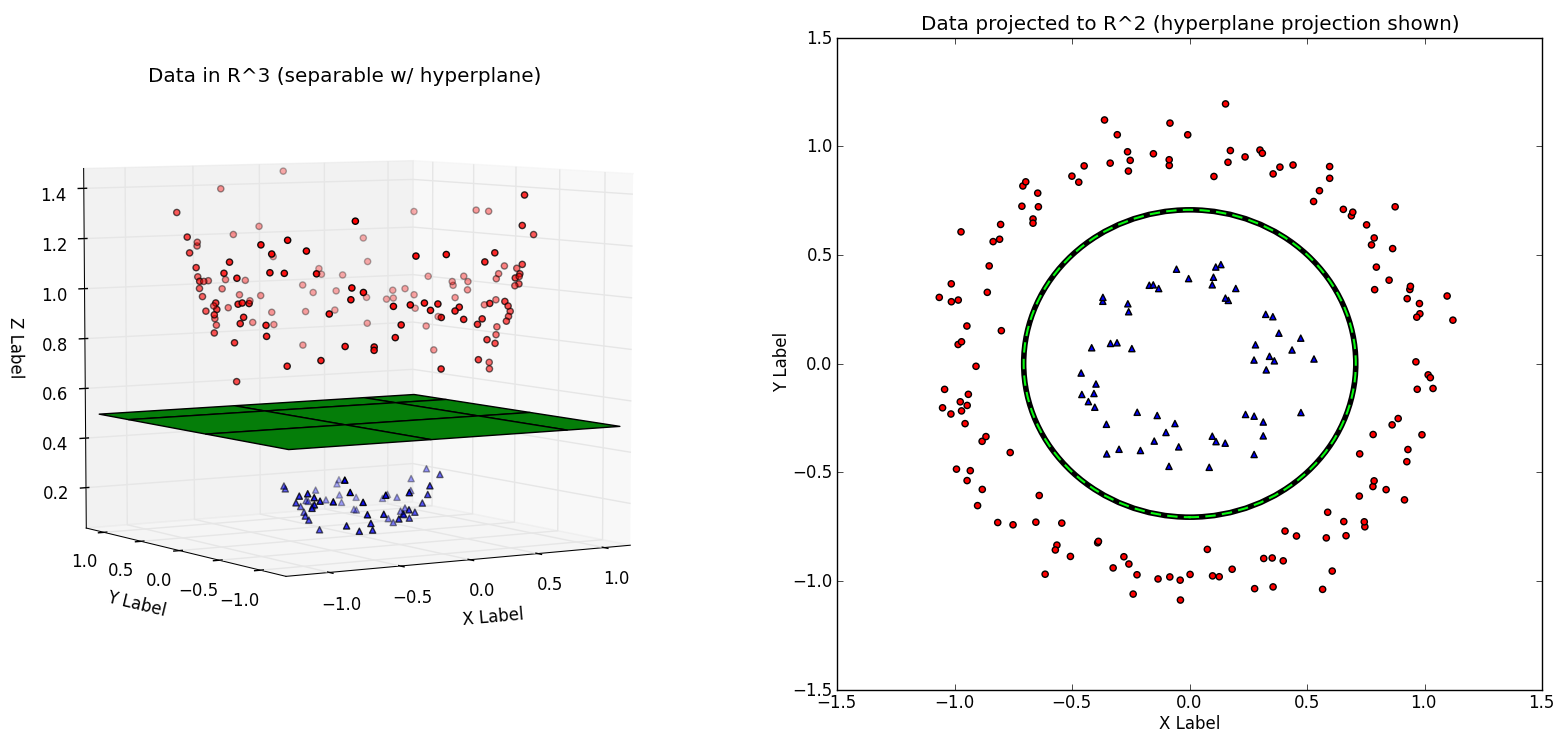

Le **théorème de Cover** généralise cette observation : 
> Des données non séparables dans $\mathbb{R}^d$ ont de grandes chances de le devenir dans un espace de dimension supérieure $\mathbb{R}^D$ (avec $D \gg d$). 

On définit donc une transformation non-linéaire :

$$\phi : \mathbb{R}^d \to \mathbb{R}^D$$

qui projette les données dans un espace de features transformées, où elles deviennent linéairement séparables. avant d'entraîner la SVM.

Le problème est que calculer $\phi(\mathbf{x})$ explicitement devient prohibitif lorsque $D \gg d$. Néanmoins, puisque la fonction de décision ne dépend des données que via les produits scalaires $\mathbf{x}_i^T\mathbf{x}$, il suffit de les remplacer par une **fonction noyau** qui calcule implicitement le produit scalaire dans l'espace transformé :

$$K(\mathbf{x}, \mathbf{x}') = \langle \phi(\mathbf{x}),\, \phi(\mathbf{x}') \rangle$$

La fonction de décision devient alors :

$$f(\mathbf{x}) = \text{sign}\!\left(\sum_{i=1}^n \alpha_i y_i\, K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

Pour être valide, $K$ doit être symétrique et semi-définie positive (condition de Mercer).

Les noyaux les plus couramment utilisés sont dans l'ordre :
1. **RBF (Radial Basis Function / Gaussien)** (peut approximer, sous certaines conditions, toute fonction continue) : $K(\mathbf{x}, \mathbf{x}') = \exp\left(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2\right)$
2. **Linéaire** (pas de projection, efficace en haute dimension) : $K(\mathbf{x}, \mathbf{x}') = \mathbf{x}^T \mathbf{x}'$
3. **Polynomial** (interactions d'ordre $p$ entre features) : $K(\mathbf{x}, \mathbf{x}') = (\gamma \mathbf{x}^T \mathbf{x}' + c)^p$
4. **Sigmoïde** (similaire aux réseaux de neurones) : $K(\mathbf{x}, \mathbf{x}') = \tanh(\gamma \mathbf{x}^T \mathbf{x}' + c)$

De manière générale, le noyaux le plus couramment utilisé est le **RBF (Radial Basis Function / Gaussien)** : $K(\mathbf{x}, \mathbf{x}') = \exp\left(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2\right)$

Sa popularité tient au fait que cette fonction projette implicitement les données dans un espace de dimension infinie (infinité de polynôme), ce qui permet d'**approximer n'importe quelle fonction continue** (sous certaines conditions).

Le paramètre $\gamma = \frac{1}{2\sigma^2}$ (avec $\sigma^2$ la variance de la gaussienne), contrôle la portée de l'influence :  
* $\gamma$ grand $\rightarrow$ influence locale $\implies$ risque de sur-apprentissage
* $\gamma$ petit $\rightarrow$ influence globale $\implies$ risque de sous-apprentissage

Néanmoins, si l'on a déjà beaucoup de dimension dans notre jeu de données on utilise généralement un noyau **linéaire** $K(\mathbf{x}, \mathbf{x}') = \mathbf{x}^T \mathbf{x}'$ qui ne projette pas dans un espace de plus grande dimension. En effet, en grande dimension les données ont de grandes chances d'être approximativement séparables, et un noyau linéaire permet une computation bien plus rapide ($O(d)$).

Etant donné la taille du vocabulaire fourni par le jeu de données ($|V| \approx 5000$), nous avons donc choisi d'utiliser un **noyau linéaire** dans ce notebook afin de maximiser l'efficacité computationnelle.


### II.3. Implémentation du SVM

On peut finalement passer à l'implémentation du SVM. On entraînera deux variantes du même pipeline, en faisant varier la représentation vectorielle (CountVectorizer ou TF-IDF) afin d'isoler l'effet de la pondération sur les performances. Le classifieur reste identique dans les deux cas : une SVM linéaire avec $C = 1$.

#### II.3.1. SVM linéaire + CountVectorizer

In [4]:
pipeline_svm_count = Pipeline([
    ('vectorizer', CountVectorizer(max_features=5000)),  # Limite à 5000 mots les plus fréquents
    ('classifier', svm.SVC(kernel='linear', C=1.0, random_state=42))
])

print("Entraînement SVM + CountVectorizer...")
start = time.time()
pipeline_svm_count.fit(x_train, y_train)
train_time = time.time() - start
print(f" -> Temps d'entraînement : {train_time//60:.2f} min")

y_pred_svm_count = pipeline_svm_count.predict(x_test)
acc_svm_count = accuracy_score(y_test, y_pred_svm_count)
print(f"\n ================= Accuracy du modèle SVM + CountVectorizer : {acc_svm_count*100:.2f} % ================= ")

Entraînement SVM + CountVectorizer...
 -> Temps d'entraînement : 95.00 min

 ================= Accuracy du modèle SVM + CountVectorizer : 85.24 % ================= 


#### II.3.2. SVM linéaire + TF-IDF

On remplace donc le CountVectorizer par un TF-IDF, qui pondère chaque terme par l'inverse de sa fréquence dans le corpus. 

Globalement, on s'attend à ce que cette pondération améliore les performances, puisque les mots très fréquents comme "hotel" ou "room", qui apparaissent dans la quasi-totalité des avis indépendamment du sentiment, verront leur contribution diminuer au profit des termes plus rares et plus discriminants comme "excellent" ou "horrible".

In [5]:
pipeline_svm_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('classifier', svm.SVC(kernel='linear', C=1.0, random_state=42))
])

print("Entraînement SVM + TF-IDF...")
start = time.time()
pipeline_svm_tfidf.fit(x_train, y_train)
train_time = time.time() - start
print(f" -> Temps d'entraînement : {train_time//60:.2f} min")

y_pred_svm_tfidf = pipeline_svm_tfidf.predict(x_test)
acc_svm_tfidf = accuracy_score(y_test, y_pred_svm_tfidf)
print(f"\n ================= Accuracy du modèle SVM + TF-IDF : {acc_svm_tfidf*100:.2f} % ================= ")

Entraînement SVM + TF-IDF...
 -> Temps d'entraînement : 5.00 min

 ================= Accuracy du modèle SVM + TF-IDF : 88.30 % ================= 


## III. Régression Logistique

La SVM que nous venons d'étudier est un modèle **discriminant géométrique**, qui ne produit pas de probabilités, mais trace directement une frontière de décision dans l'espace des représentations. La régression logistique adopte une perspective différente, en modélisant explicitement la probabilité conditionnelle $P(y \mid \mathbf{x})$.

Cette distinction permet de quantifier l'incertitude du modèle, de calibrer les décisions selon un seuil variable, et d'interpréter les poids $(\mathbf{w},b)$ comme des effets sur le log-rapport de probabilités. C'est pourquoi la régression logistique, malgré sa simplicité, reste une méthode de référence incontournable.

### III.1. Du logit à la sigmoïde

L'objectif est de modéliser $P(Y = 1 \mid \mathbf{x})$, la probabilité d'appartenir à la classe positive sachant l'observation $\mathbf{x}$. La sortie de notre modèle doit donc être comprise entre 0 et 1, ce qui empêche d'utiliser un modèle purement linéaire $\mathbf{w}^T \mathbf{x} + b$ dont la plage est $(-\infty, +\infty)$ pour la modéliser.

Pour que la sortie soit comprise entre 0 et 1, on modélise la probabilité $P(Y = 1 \mid \mathbf{x})$ par :

$$P(Y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

où $\sigma$ désigne la **fonction sigmoïde**. Elle écrase n'importe quelle valeur réelle dans l'intervalle $(0, 1)$, vaut $0.5$ lorsque $\mathbf{w}^T \mathbf{x} + b = 0$ (ie. sur l'hyperplan de décision), et tend vers 0 ou 1 plus on s'éloigne de cet hyperplan.

Concrètement, pour retrouver cette modélisation, on doit partir de la supposition que le **log-rapport de cotes** (ou *logit*) de $P(Y = 1 \mid \mathbf{x})$ est une fonction linéaire de $\mathbf{x}$. 

En effet, le rapport de cotes (*odds ratio*) est défini par :

$$\text{odds} = \frac{P(Y = 1 \mid \mathbf{x})}{1 - P(Y = 1 \mid \mathbf{x})}$$

Il varie dans $(0, +\infty)$ et mesure combien la classe positive est plus probable que la classe négative. Son logarithme (le logit) prend ses valeurs dans $(-\infty, +\infty)$, ce qui le rend compatible avec une modélisation linéaire :

$$\log\!\left(\frac{P(Y = 1 \mid \mathbf{x})}{1 - P(Y = 1 \mid \mathbf{x})}\right) = \mathbf{w}^T \mathbf{x} + b$$

En résolvant cette équation pour $P(Y = 1 \mid \mathbf{x})$, on obtient la fonction de prédiction du modèle :

$$\boxed{P(Y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}}$$

La règle de décision associée est alors :

$$f(\mathbf{x}) = \begin{cases} +1 & \text{si } \sigma(\mathbf{w}^T \mathbf{x} + b) > 0.5 \\ -1 & \text{sinon} \end{cases}$$

ce qui revient à regarder, comme pour la SVM linéaire, de quel côté de l'hyperplan $\mathbf{w}^T \mathbf{x} + b = 0$ se trouve le point. La différence fondamentale est que la régression logistique fournit en plus une **confiance** associée à chaque prédiction, via la valeur de $\sigma(\mathbf{w}^T \mathbf{x} + b)$.

### III.2. Apprentissage par maximum de vraisemblance

Il reste à déterminer comment trouver les paramètres $(\mathbf{w}, b)$ qui approxime le mieux les données d'entraînement, tout en évitant le suraprentissage. Le principe du **maximum de vraisemblance** consiste à choisir les paramètres qui maximisent la probabilité d'avoir observé les étiquettes $y_1, \ldots, y_n$ sachant les entrées $\mathbf{x}_1, \ldots, \mathbf{x}_n$.

**En supposant les observations indépendantes**, la vraisemblance s'écrit :

$$\mathcal{L}(\mathbf{w}, b) = \prod_{i=1}^n P(Y = y_i \mid \mathbf{x}_i;\, \mathbf{w}, b)$$

Pour un problème binaire avec $y_i \in \{0, 1\}$, la probabilité du label $y_i$ peut s'écrire de façon compacte (en notant $\hat{p}_i = \sigma(\mathbf{w}^T \mathbf{x}_i + b)$) selon la loi de Bernoulli :

$$P(Y = y_i \mid \mathbf{x}_i) = \hat{p}_i^{\,y_i} \cdot (1 - \hat{p}_i)^{1-y_i}$$

*Note : on utilise ici $y_i \in \{0, 1\}$, plutôt que $\{-1, +1\}$, pour se rapprocher de la formulation de la loi de Bernoulli.*

En pratique, maximiser la vraissemblance $\mathcal{L}$ est équivalent à minimiser son logarithme négatif, la **log-vraisemblance négative**, aussi appelée **cross-entropie** :

$$\min_{\mathbf{w}, b} \, -\log \mathcal{L}(\mathbf{w}, b) = \min_{\mathbf{w}, b} \, -\sum_{i=1}^n \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Ce passage du produit à la somme (grâce au logarithme) rend l'optimisation bien plus maniable. De plus, le logarithme projettent les probabibilités comprises entre 0 et 1, sur $\left]-\infty, 0\right]$. La cross-entropie pénalise alors fortement le modèle lorsqu'il attribue une faible probabilité à l'étiquette correcte (si $y_i = 1$ mais que $\hat{p}_i \approx 0$, le terme $-\log \hat{p}_i$ devient très grand).

Pour éviter le surapprentissage et maximiser la marge, on ajoute un terme de **régularisation L2** :

$$\min_{\mathbf{w}, b} \quad -\sum_{i=1}^n \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right] + \frac{1}{2C} \|\mathbf{w}\|^2$$

Le paramètre $C > 0$ (convention scikit-learn, inverse du $\lambda$ habituel) joue le même rôle que dans la SVM : un $C$ grand réduit la pénalité et autorise des poids plus grands, au risque d'un surapprentissage, tandis qu'un $C$ petit force les poids vers zéro et produit un modèle plus régulier.

**Remarque — Régularisation L1 :** On peut également remplacer le terme L2 par une pénalité L1 $\lambda \sum_j |w_j|$, dont les coins non-différentiables en zéro ont la propriété de forcer certains poids à zéro. La L1 réalise ainsi une **sélection de features** automatique, utile lorsque le vocabulaire est très grand et que l'on souspecte que seule une fraction des mots est réellement discriminante.

### III.3. Optimisation : de la descente de gradient aux solveurs

La cross-entropie régularisée ainsi obtenue est une fonction convexe et différentiable de $(\mathbf{w}, b)$. Cependant, contrairement aux moindres carrés en régression linéaire, elle n'admet pas de solution analytique en **forme fermée**.

*Cf : [Chapitre 10 - Régression Linéaire](https://github.com/clothilde-ml/MT94-Mathematiques-Appliquees/blob/main/10-Regression_lin.ipynb) disponible dans le répertoire "MT94 - mathématiques appliquées" de mon GitHub*

Pour approximer cette perte, il faut donc recourir à des méthodes itératives comme la méthode de Newton présentée dans le [Chapitre 11 - Régression non Linéaire](https://github.com/clothilde-ml/MT94-Mathematiques-Appliquees/blob/main/11-Regression_non_lin.ipynb). 

Ce chapitre s'attarde longuement sur la démonstration du calcul derrière l'approximation de la loss-function par la méthode de Newton. Mais on peut comprendre le principe de la régression logistique en ne s'intéressant qu'à la simple descente de gradient (qui ne demande pas de calculer la Hessienne).

#### III.3.1. Descente de gradient

Le principe de la **descente de gradient** est de partir d'une initialisation arbitraire $\mathbf{w}^{(0)}$ et de mettre à jour les paramètres en suivant la direction opposée au gradient de la fonction de coût $\mathcal{L}(\mathbf{w}, b)$ :

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \,\nabla_\mathbf{w}\, \mathcal{L}(\mathbf{w}^{(t)}, b^{(t)})$$

où $\eta > 0$ est le **taux d'apprentissage** (*learning rate*). 

L'avantage de cette méthode vient du fait que le gradient de la cross-entropie par rapport à $\mathbf{w}$ a une forme remarquablement simple :

$$\nabla_\mathbf{w}\, \mathcal{L} = -\sum_{i=1}^n \left(y_i - \hat{p}_i\right) \mathbf{x}_i + \frac{1}{C}\mathbf{w} = \sum_{i=1}^n \underbrace{(\hat{p}_i - y_i)}_{\text{erreur}} \mathbf{x}_i + \frac{1}{C}\mathbf{w}$$

Ainsi, chaque itération corrige $\mathbf{w}$ proportionnellement à l'erreur de prédiction $(\hat{p}_i - y_i)$ sur chaque exemple, pondérée par $\mathbf{x}_i$. Le terme de régularisation $\frac{1}{C}\mathbf{w}$ tire doucement les poids vers zéro à chaque pas. 

Cependant, cette méthode demande donc de calculer le gradient sur l'ensemble du jeu de données à chaque itération, ce qui devient coûteux pour un nombre de documents $n$ grand et pousse le modèle vers le surapprentissage.

#### III.3.2. Variantes et solveurs

En pratique, la descente de gradient de base est ainsi rarement utilisée telle quelle. En effet, il existe plusieurs variantes qui en améliorent l'efficacité en exploitant la structure de la fonction de coût ou la taille du corpus. On peut notament citer :

* Le **Gradient Stochastique (SGD)** qui, au lieu de sommer les contributions de tous les $n$ exemples à chaque pas, tire aléatoirement un seul exemple (ou un mini-batch) et met à jour $\mathbf{w}$ depuis son gradient partiel. Chaque itération est en $O(d)$ (ou $O(\text{taille-batch}.d)$) au lieu de $O(nd)$, ce qui rend la méthode scalable, mais introduit du bruit dans la descente. *On abordera plus en profondeur cette technique dans le chapitre III.*

* Les méthodes à **Gradient Stochastique Moyenné** (*Stochastic Average Gradient*, **SAG / SAGA**) qui corrigent le bruit du SGD en maintenant une table des gradients passés. À chaque itération, elles mettent à jour le gradient d'un seul exemple *et* l'incorporent à la moyenne mémorisée, ce qui permet de converger à la vitesse du gradient complet tout en conservant le coût par itération du SGD. `saga` étend `sag` en supportant la régularisation L1.

* Les **Méthodes de Newton** qui, plutôt que de suivre uniquement le gradient (dérivée première), exploitent aussi la **courbure** de la fonction de coût via la hessienne $\nabla^2 \mathcal{L}$ (matrice des dérivées secondes). Le principe est qu'un gradient large dans une direction très courbée mérite un pas plus petit qu'un gradient identique dans une direction plate. La mise à jour de Newton est $\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - (\nabla^2 \mathcal{L})^{-1} \nabla \mathcal{L}$, ce qui converge en beaucoup moins d'itérations, au prix du calcul et du stockage de la hessienne, qui peut-être prohibitif en haute dimension.

* Enfin, le **L-BFGS** (*Limited-memory BFGS*) est le compromis retenu par défaut dans scikit-learn. Au lieu de calculer explicitement la hessienne ($O(d^2)$ en mémoire), L-BFGS en construit une **approximation rang-faible** à partir des $m$ dernières paires gradient/déplacement (typiquement $m = 10$). On bénéficie ainsi de la convergence rapide des méthodes quasi-newtoniennes avec un coût mémoire en $O(md)$ seulement. C'est le solveur le plus efficace pour les jeux de données de taille petite à moyenne avec régularisation L2.

Pour notre jeu de données ($n \approx 30\,000$ modéré, $d = 5\,000$), `lbfgs` reste donc le choix le plus adapté pour une convergence rapide.

### III.3. Implémentation de la régression logistique + TF-IDF

On utilise ici la TF-IDF comme représentation, qui s'est révélé plus performante que le CountVectorizer pour les modèles discriminants lors de nos expérimentations avec la SVM. 

#### III.4.1. Régression logistique + TF-IDF

In [6]:
pipeline_logreg = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('classifier', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

print("Entraînement Logistic Regression + TF-IDF...")
start = time.time()
pipeline_logreg.fit(x_train, y_train)
train_time = time.time() - start
print(f" -> Temps d'entraînement : {train_time:.2f} sec")


y_pred_logreg = pipeline_logreg.predict(x_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Accuracy : {acc_logreg:.4f} ({acc_logreg*100:.2f}%)")
print(f"\n ================= Accuracy du modèle Régression Linéaire + TF-IDF : {acc_logreg*100:.2f} % ================= ")

Entraînement Logistic Regression + TF-IDF...
 -> Temps d'entraînement : 3.50 sec
Accuracy : 0.8831 (88.31%)

 ================= Accuracy du modèle Régression Linéaire + TF-IDF : 88.31 % ================= 


## IV. Naive Bayes : approche générative

On a donc pu aborder deux modèles (le SVM et la régression logistique) qui ont pour point commun d'être tous deux **discriminants**, puisqu'ils cherchent à modéliser $P(Y \mid \mathbf{x})$, la probabilité de la classe sachant l'observation. 

Dans cette partie, on adoptera une perspective radicalement différente, en modélisant d'abord comment chaque classe *génère* les données, pour en déduire ensuite la décision de classification.

Cette distinction entre modèles discriminants et génératifs est fondamentale en apprentissage automatique. En effet, les modèles génératifs demandent de représenter la distribution des données $x$ sur $d$ dimensions (ie. la distribution jointe $P(x_1,\cdots , x_d)$), un problème bien plus difficile (sans hypothèse naïve) que la formulation de la distribution conditionnelle $P(Y=1 \mid \mathbf{x})$. 

On introduit donc dans cette partie, un premier modèle génératif : le Naive Bayes, qui permet de traiter facilement la distribution des données depuis une hypothèse dite "naïve". L'objectif ici sera surtout de présenter un modèle particulièrement populaire en classification binaire (notamment pour le filtrage de spams), puisqu'il est à la fois léger, rapide à entraîner et souvent étonnamment efficace malgré son hypothèse simplificatrice.

Les modèles génératifs classiques, sans hypothèse naïve, seront quant à eux abordés dans le tout dernier chapitre ce ce cahier.

### IV.1. Modèles génératifs et théorème de Bayes

Un **modèle génératif**, comme le Naive Bayes, ne modélise donc pas directement $P(Y \mid \mathbf{x})$, mais la distribution jointe $P(\mathbf{x}, Y) = P(\mathbf{x} \mid Y) \cdot P(Y)$. Autrement dit, pour chaque classe $c$, il apprend un modèle de la distribution des données que cette classe est susceptible de produire. La classification découle ensuite de ces modèles via le **théorème de Bayes** :

$$P(Y = c \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid Y = c) \cdot P(Y = c)}{P(\mathbf{x})}$$

où $P(Y = c)$ est la **probabilité a priori** de la classe $c$ (donc sa fréquence dans le corpus d'entraînement), et $P(\mathbf{x} \mid Y = c)$ est la **vraisemblance** du document $\mathbf{x}$ sous la classe $c$.

La règle de décision choisit la classe qui maximise la probabilité **a posteriori** :

$$\hat{y} = \arg\max_{c}\; P(Y = c \mid \mathbf{x}) = \arg\max_{c}\; P(\mathbf{x} \mid Y = c) \cdot P(Y = c)$$

En effet, comme le dénominateur $P(\mathbf{x})$ est identique pour toutes les classes, il peut être retiré sous l'opération $\arg\max_c$.

Un modèle génératif comme Naive Bayes apprend donc une description de chaque classe, et c'est la comparaison de ces descriptions qui produit la frontière.

### IV.2. L'hypothèse naïve d'indépendance conditionnelle

Comme on vient de l'expliquer, la difficulté de l'approche générative est de modéliser $P(\mathbf{x} \mid Y = c)$, la distribution jointe de toutes les features de $\mathbf{x} \in \mathbb{R}^{|V|}$ dans chaque classe.

L'hypothèse naïve qui permet de la rendre facilement calculable, consiste à supposer que les features sont **conditionnellement indépendantes** sachant la classe :

$$P(\mathbf{x} \mid Y = c) = \prod_{j=1}^{|V|} P(x_j \mid Y = c)$$

Sous cette hypothèse, la distribution jointe se factorise en un simple produit de distributions marginales, chacune estimable séparément depuis les données. On passe donc d'un problème exponentiel en $|V|$ à un problème linéaire.

A noter que cette hypothèse est évidemment fausse puisque, par exemple, dans un avis, les mots "chambre" et "propre" ne sont clairement pas indépendants. Toutefois, en pratique, le modèle performe étonnamment bien. 

La raison de ces bonnes performances tient au fait que la règle de décision $\arg\max$ ne requiert pas que les probabilités soient bien calibrées, mais seulement que la classe correcte soit *rangée* plus haut que les autres. Même si les $P(Y = c \mid \mathbf{x})$ sont distordues par l'indépendance conditionnelle, leur ordre relatif reste souvent préservé.

### IV.3. Choisir un modèle pour $P(x_j \mid Y = c)$

L'hypothèse d'indépendance ramène le problème à l'estimation de chaque $P(x_j \mid Y = c)$ séparément. La forme de cette distribution dépend de la nature de la feature $x_j$ (comptage, présence/absence, ou mesure continue). Les trois cas donnent trois variantes de Naive Bayes, dont les règles de décision partagent la même structure mais diffèrent dans la façon dont la vraisemblance est calculée.

#### IV.3.1. Naive Bayes multinomial : données de comptage

Lorsque $x_j$ est le nombre d'occurrences du mot $w_j$ dans le document (CountVectorizer), on modélise la génération du document comme un tirage multinomial : on tire $N = \sum_j x_j$ mots indépendamment, en choisissant à chaque tirage le mot $w_j$ avec probabilité $P(w_j \mid Y = c)$. La probabilité d'obtenir exactement le vecteur de comptages $\mathbf{x}$ est alors donnée par la loi multinomiale :

$$P(\mathbf{x} \mid Y = c) = \frac{N!}{\prod_j x_j!} \prod_{j=1}^{|V|} P(w_j \mid Y = c)^{x_j}$$

Le coefficient multinomial $\frac{N!}{\prod_j x_j!}$ (qui généralise à $|V|$ catégories le coefficent binomial $\binom{N}{k} = \frac{N!}{k!(N-k)!}$), ne dépend pas de la classe $c$ et disparaît donc de l'$\arg\max$.

Pour éviter les sous-dépassements numériques, on passant par le logarithme, et la règle de décision devient :

$$\hat{y} = \arg\max_{c} \left[ \log P(Y = c) + \sum_{j=1}^{|V|} x_j \log P(w_j \mid Y = c) \right]$$

Les paramètres $P(w_j \mid Y = c)$ s'estiment finalement par comptage direct sur le corpus d'entraînement : $P(w_j \mid Y = c) = N_{jc} / N_c$

où $N_{jc} = \sum_{i=1:\, y_i = c}^n x_{ij}$ est le nombre total d'occurrences du mot $w_j$ dans les documents de classe $c$, et $N_c= \sum_{j'=1}^{|V|} N_{j'c}$ est le nombre total de mots dans les documents de classe $c$.

Le problème avec cet estimation de $P(w_j \mid Y = c)$ est qu'elle s'annule si un mot $w_j$ n'apparaît jamais dans les documents de classe $c$ lors de l'entraînement ($N_{jc}=0$), ce qui annule la vraisemblance entière entre le document et la classe $c$ dès que ce mot apparaît dans le test, quelle que soit l'importance des autres features. 

Dans ce sens, on peut imaginer qu'un usager pourrait utiliser cette faille pour contourner un système de détectage de spam, simplement en insérant un mot absent dans le corpus d'entrainement dans son mail.

Pour éviter ces probabilités nulles, on ajoute donc un **pseudo-comptage** $\alpha > 0$ à chaque mot dans chaque classe :

$$P(w_j \mid Y = c) = \frac{N_{jc} + \alpha}{N_c + \alpha\, |V|}$$

Le dénominateur $N_c + \alpha\,|V|$ assure que les probabilités restent normalisées. Ce lissage revient à supposer avoir observé chaque mot au moins $\alpha$ fois dans chaque classe avant de voir les données. Dans ce scikit-learn, le pseudo-comptage vaut 1 par défaut : `MultinomialNB(alpha=1.0)`.

#### IV.3.2. Naive Bayes de Bernoulli : données de présence/absence

Si l'on ne s'intéresse qu'à la **présence ou l'absence** d'un mot dans le document, chaque feature $x_j \in \{0, 1\}$ ne suit qu'une simple loi de Bernoulli de paramètre $p_{jc} = P(x_j = 1 \mid Y = c)$. La vraisemblance d'un document s'écrit alors :

$$P(\mathbf{x} \mid Y = c) = \prod_{j=1}^{|V|} p_{jc}^{x_j} (1 - p_{jc})^{1 - x_j}$$

Ce qui est intéressant dans cette variante est que l'absence d'un mot contribue explicitement à la vraisemblance par $(1 - p_{jc})^{1-x_j}$, ce que le modèle multinomial ne fait pas. Un mot très fréquent dans la classe $c$ mais absent du document devient alors un signal négatif fort. Cette formulation est cependant généralement mieux adaptée aux représentations binaires et aux documents courts, où la distinction comptage/présence a peu d'importance.

#### IV.3.3. Naive Bayes gaussien : features continues

Lorsque les features ne sont pas des comptages mais des mesures continues, on s'appuie sur l'hypothèse qui sous-tend le théorème central limite en modélisant $P(x_j \mid Y = c)$ par une gaussienne de moyenne $\mu_{jc}$ et de variance $\sigma_{jc}^2$, estimées empiriquement sur les exemples de classe $c$ :

$$P(x_j \mid Y = c) = \frac{1}{\sqrt{2\pi\sigma_{jc}^2}} \exp\!\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)$$

En passant au logarithme, la contribution à la décision devient finalement la pénalisation quadratique de l’écart à la moyenne $-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}$.


Ces trois variantes permettent ainsi toutes de respecter l'hypothèse Naive d'indépendance des features. Elles partagent la même règle de décision :
$$\arg\max \,\log P(Y = c) + \sum_j \log P(x_j \mid Y = c)$$
où seule la forme du terme $\log P(x_j \mid Y = c)$ change selon la distribution choisie.

### IV.4. Implémentation du Naive Bayes multinomial

Contrairement à la SVM et à la régression logistique, le Naive Bayes n'emploie pas la TF-IDF pour traiter du texte. En effet, avec des données textuelles, la façon la plus optimale de l'utiliser est avec une modélisation multinomiale sur un vecteur de comptage (CountVectorizer).

### IV.4.1. Implémentation Naive Bayes Multinomial + CountVectorizer


In [7]:
pipeline_nb = Pipeline([
    ('vectorizer', CountVectorizer(max_features=5000)),
    ('classifier', MultinomialNB(alpha=1.0))
])

print("Entraînement Naive Bayes + CountVectorizer...")
start = time.time()
pipeline_nb.fit(x_train, y_train)
train_time = time.time() - start
print(f" -> Temps d'entraînement : {train_time:.2f} sec")

y_pred_nb = pipeline_nb.predict(x_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"\n ================= Accuracy du modèle Naive Bayes : {acc_nb*100:.2f} % ================= ")

Entraînement Naive Bayes + CountVectorizer...
 -> Temps d'entraînement : 3.10 sec

 ================= Accuracy du modèle Naive Bayes : 86.42 % ================= 


## V. Analyse Comparative des méthodes et Recommandations

### V.1. Évaluer un modèle : métriques et outils d'analyse

Avant de comparer les modèles entre eux, il faut s'entendre sur ce que signifie "bien performer". En effet, comme nous l'avons vu lors du chargement du dataset, les classes sont quelques peu déséquilibrée ($\approx$ 68% "Satisfait" contre 32% "Insatisfait"). Ainsi, selon les métriques utilisées on peut obtenir des résultats très différents reflétant des façons de performer très différentes entre les modèles.

#### V.1.1. La matrice de confusion

La **matrice de confusion** croise les étiquettes réelles avec les prédictions du modèle et produit quatre comptages :

|  | **Prédit : Positif** | **Prédit : Négatif** |
|---|---|---|
| **Réel : Positif** | Vrai Positif (TP) | Faux Négatif (FN) |
| **Réel : Négatif** | Faux Positif (FP) | Vrai Négatif (TN) |

Dans notre contexte, la classe positive est la classe **Satisfait** (0). Un **TP** est donc un avis positif correctement identifié, un **FN** un avis positif signalé comme négatif, un **FP** un avis négatif manqué, et un **TN** un avis négatif correctement identifié. 

La matrice de confusion permet ainsi de voir *où* un modèle se trompe, et pas seulement combien de fois.

A noter que pour plus de clareté on a pris la classe Satisfait comme étant la classe positive. Mais dans ce genre d'application, on cherche généralement plus à detecter les avis négatifs, et on considère donc que la classe positive est la classe Insatisfait.

#### V.1.2. Les métriques scalaires

À partir de ces quatre comptages, on peut définir plusieurs métriques, chacune répondant à une question différente.

**L'Accuracy** mesure la proportion globale de prédictions correctes :

$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

Cette mesure est globalement trompeuse sur des données déséquilibrées puisqu'un modèle qui prédirait toujours "Satisfait" atteindrait déjà $68\,\%$ sans avoir rien appris et sans n'être d'aucune aide pour détecter les avis négatifs.

**La Précision** mesure, parmi les exemples classés positifs, quelle fraction l'était vraiment :

$$\text{Précision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

**Le Rappel** mesure, parmi les exemples réellement positifs, quelle fraction le modèle a détectée :

$$\text{Rappel} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

Globalement, les mesures de précision et de rappel sont inversement liées. En effet, un modèle très prudent aura une précision élevée mais manquera beaucoup de vrais positifs (rappel moins bon) ; un modèle trop agressif aura un bon rappel mais produira beaucoup de fausses alertes (précision moins bonne). Sur des données déséquilibrées, les modèles tendent naturellement à sacrifier le rappel, puisque la classe minoritaire est plus difficile à détecter.

**Le F1-Score** réconcilie les deux en calculant leur moyenne harmonique :

$$F_1 = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}$$

Un F1 élevé exige que précision et rappel soient simultanément satisfaisants. C'est le critère principal que nous utiliserons pour comparer les modèles dans ce qui suit.

### V.2. Comparaison des méthodes



In [8]:
# Calcul des métriques détaillées pour chaque modèle
models = {
    'SVM + CountVectorizer': y_pred_svm_count,
    'SVM + TF-IDF': y_pred_svm_tfidf,
    'Logistic Regression + TF-IDF': y_pred_logreg,
    'Naive Bayes + CountVectorizer': y_pred_nb
}

results = []     # résultats pour le tableau comparatif
raw_metrics = {} # résultats bruts pour les autres graphiques

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Modèle': name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}"
    })
    
    raw_metrics[name] = [acc, prec, rec, f1]

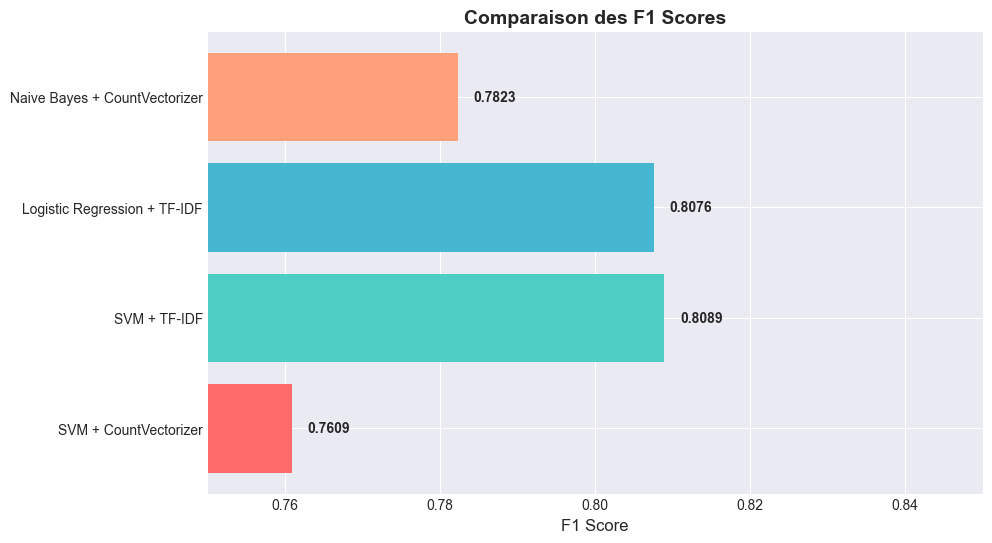


 Meilleur modèle : SVM + TF-IDF (F1 Score : 0.8089)


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(raw_metrics.keys())
f1_scores = [metrics[3] for metrics in raw_metrics.values()] 

ax.barh(model_names, f1_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Comparaison des F1 Scores', fontsize=14, fontweight='bold')
ax.set_xlim([0.75, 0.85])
for i, v in enumerate(f1_scores):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

axes = np.array([ax, ax])
plt.show()

# Meilleur modèle
best_idx = np.argmax(f1_scores)
best_model_name = model_names[best_idx]
print(f"\n Meilleur modèle : {best_model_name} (F1 Score : {f1_scores[best_idx]:.4f})")

#### V.2.2. Comparatif des Matrice de confusion de chaque méthode

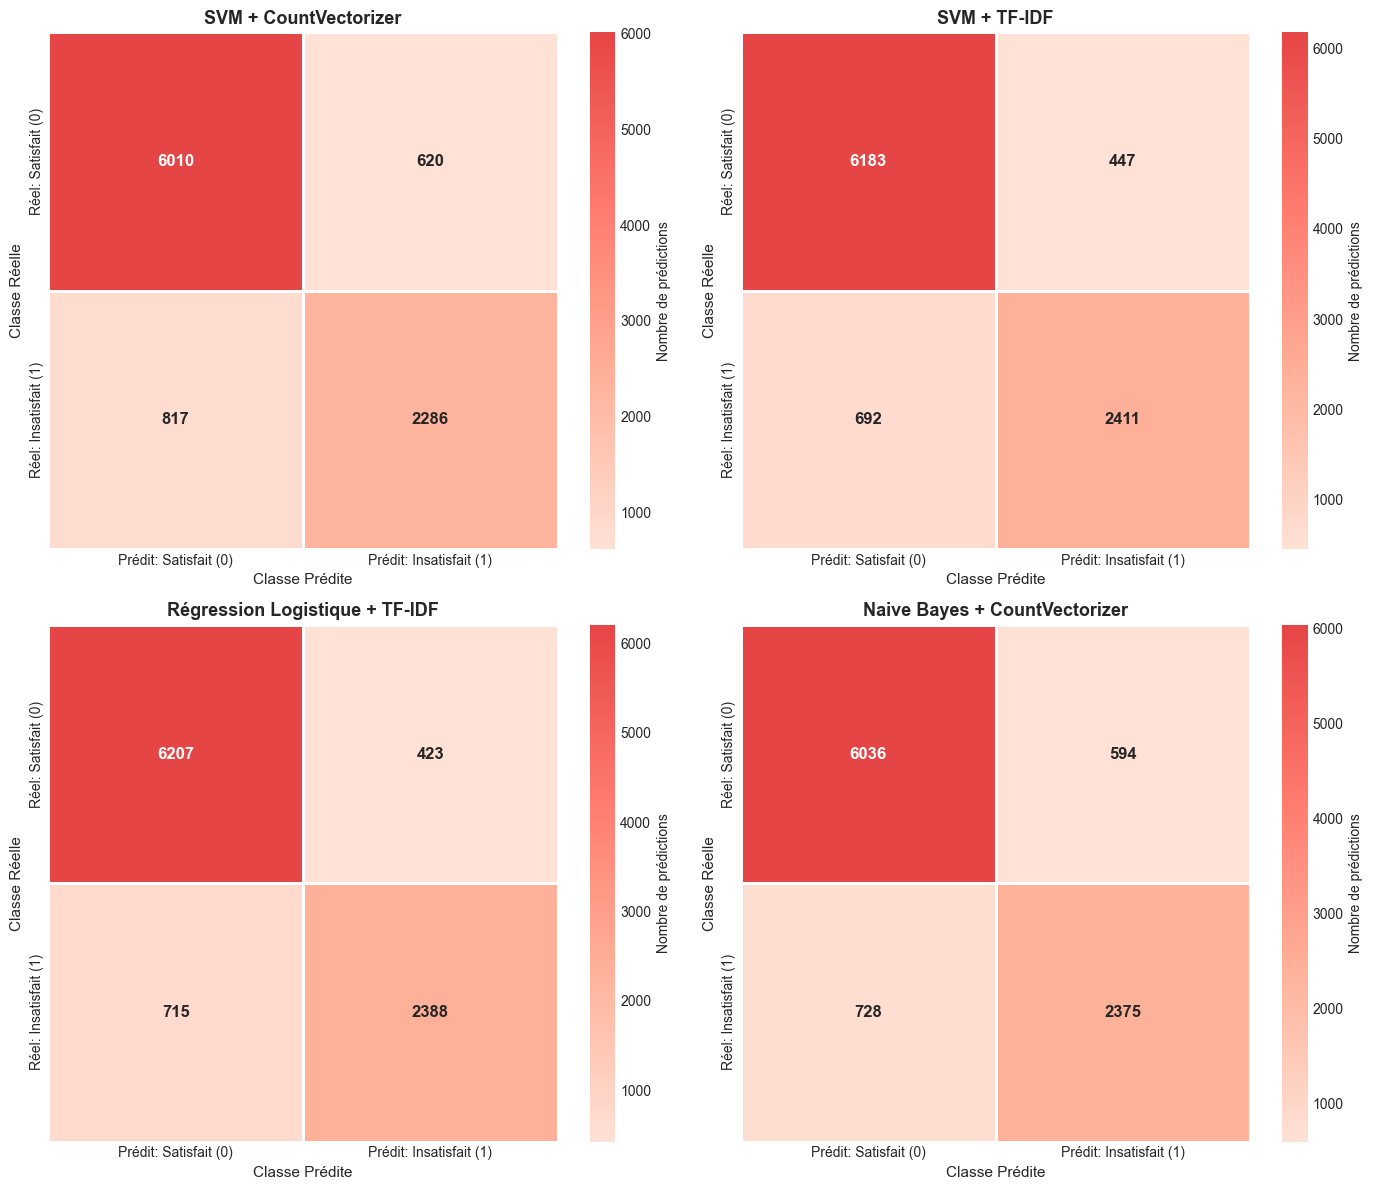

In [23]:
def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    conf_matrix = pd.DataFrame(
        data=cm,
        columns=['Prédit: Satisfait (0)', 'Prédit: Insatisfait (1)'],
        index=['Réel: Satisfait (0)', 'Réel: Insatisfait (1)']
    )
    
    colors = ["#FFE1D6", "#FFB199", "#FF7A6E", "#E64545"]
    custom_cmap = LinearSegmentedColormap.from_list("custom", colors)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=custom_cmap,
                cbar_kws={'label': 'Nombre de prédictions'},
                linewidths=2, linecolor='white',
                annot_kws={'size': 12, 'weight': 'bold'},
                ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Classe Réelle', fontsize=11)
    ax.set_xlabel('Classe Prédite', fontsize=11)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_confusion(axes[0, 0], y_test, y_pred_svm_count,
               "SVM + CountVectorizer")

plot_confusion(axes[0, 1], y_test, y_pred_svm_tfidf,
               "SVM + TF-IDF")

plot_confusion(axes[1, 0], y_test, y_pred_logreg,
               "Régression Logistique + TF-IDF")

plot_confusion(axes[1, 1], y_test, y_pred_nb,
               "Naive Bayes + CountVectorizer")

plt.tight_layout()
plt.show()


#### V.2.2. Tableau Comparatif des Résultats

In [11]:
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("COMPARAISON DES PERFORMANCES ENTRE MODELES")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


COMPARAISON DES PERFORMANCES ENTRE MODELES
                       Modèle Accuracy Precision Recall F1-Score
        SVM + CountVectorizer   0.8524    0.7866 0.7367   0.7609
                 SVM + TF-IDF   0.8830    0.8436 0.7770   0.8089
 Logistic Regression + TF-IDF   0.8831    0.8495 0.7696   0.8076
Naive Bayes + CountVectorizer   0.8642    0.7999 0.7654   0.7823


### V.3. Analyse des deux Meilleurs Modèles : SVM + TF-IDF / Logistic Regression + TF-IDF

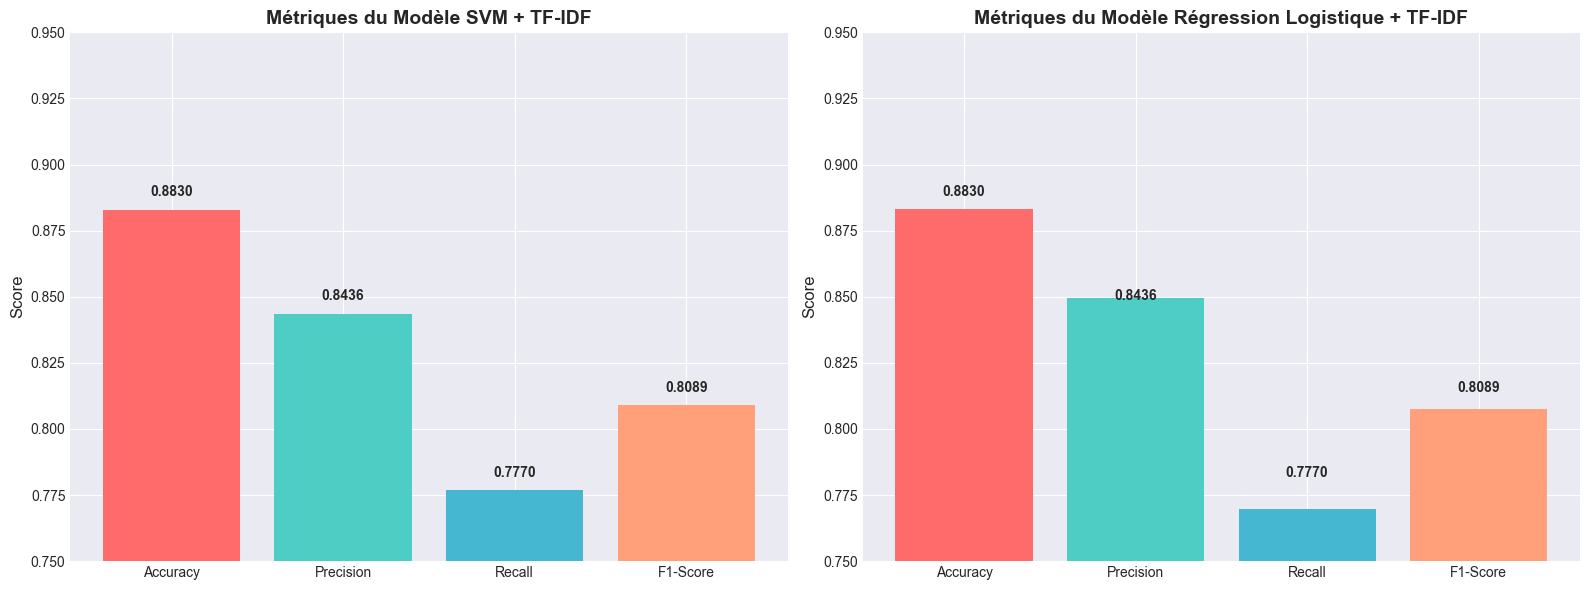

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

axes[0].bar(metrics_names, raw_metrics['SVM + TF-IDF'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Métriques du Modèle SVM + TF-IDF', fontsize=14, fontweight='bold')
axes[0].set_ylim([0.75, 0.95])
for i, v in enumerate(raw_metrics['SVM + TF-IDF']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(metrics_names, raw_metrics['Logistic Regression + TF-IDF'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Métriques du Modèle Régression Logistique + TF-IDF', fontsize=14, fontweight='bold')
axes[1].set_ylim([0.75, 0.95])
for i, v in enumerate(raw_metrics['SVM + TF-IDF']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### V.4. Synthèse des résultats

Les résultats montrent donc de façon assez nette l'intérêt des deux modèles discriminants associés au TF-IDF (SVM et régression logistique), qui dominent le classement avec un F1-score d'environ 0.81.

On peut s'intéresser en particulier au passage du CountVectorizer à la TF-IDF pour la SVM, qui a permis de gagner 2.5 points sur le F1-score. Concrètement, le TF-IDF a permis de réduire les poids des mots omniprésents et indépendant du sentiment comme "hotel" ou "room", et d'amplifier ceux des termes discriminants comme "excellent" ou "horrible".

La SVM obtient la meilleure sensibilité (rappel $\approx 0.777$) et le meilleur F1-Score ($\approx 0.809$), ce qui en fait le modèle le plus adapté à notre contexte de déséquilibre de classes : elle détecte une plus grande fraction des avis négatifs, au prix d'une précision légèrement inférieure à celle de la régression logistique.

La régression logistique est néanmoins plus rapide à entraîner et produit des probabilités calibrées, ce qui la rend préférable dans les cas où l'on a besoin d'un score de confiance en plus de la décision binaire.

Le Naive Bayes quant à lui, se distingue par sa rapidité d'entraînement (non-itératif), mais ses performances inférieures reflètent le coût de l'hypothèse d'indépendance conditionnelle, qui n'est pas vérifiée dans un avis pour des hôtels (où l'information sémantique se cache souvent dans les relations entre les mots).

## VI. Améliorations possibles

Les performances assez faibles des modèles souligne une limite commune entre ces derniers. En effet, tous les modèles reposent sur une représentation Bag-of-Words qui est une vision assez limitée de la sémantique des avis.

Cette limitation n'invalide pas les modèles puisqu'un F1-score de 0.81 reste solide sur un corpus de $40\,000$ avis, mais elle indique la direction des améliorations possibles, que nous explorerons dans la section suivante.

### VI.1. Améliorer la représentation

#### VI.1.1. Capturer le contexte local : les n-grammes

Comme nous l'avons expliqué, la TF-IDF attribue un poids à chaque mot *individuellement*. La négation "pas cher" reçoit ainsi deux tokens distincts ("pas" et "cher") dont le second porte généralement un poids négatif, là où l'expression dans son ensemble est plutôt positive. Plus généralement, toute construction où le sens émerge d'une séquence de mots consécutifs (comme avec des négations, superlatifs, locutions) échappe à la pondération par unigrammes.

Les **n-grammes** étendent ainsi le vocabulaire en ajoutant des tokens multi-mots : un bigramme comme "pas cher" ou "très bien" devient une feature à part entière, dont le poids TF-IDF est appris indépendamment de ses composants. Pour utiliser des n-grammes, on utilise le paramètre `ngram_range` de Scikit-learn :
```python
TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)
```

La contrepartie de cette méthode est que le vocabulaire croît combinatoriellement avec $n$ (passer de unigrammes à uni+bigrammes triple environ la taille de $V$), ce qui augmente le temps d'entraînement et le risque de surapprentissage si `max_features` n'est pas ajusté en conséquence.

Le paramètre `min_df=2` permet ainsi d'éliminer les bigrammes n'apparaissant qu'une seule fois dans le corpus, qui seraient trop rares pour être estimés fiablement et gonfleraient inutilement le vocabulaire. 

In [13]:
vectorizer_bigram = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2
)

svm_bigram = Pipeline([
    ('vectorizer', vectorizer_bigram),
    ('classifier', svm.SVC(kernel='linear', C=1.0, random_state=42))
])

# Entraînement
svm_bigram.fit(x_train, y_train)

y_pred_svm_bigram = svm_bigram.predict(x_test)
f1_score_svm_bigram = f1_score(y_test, y_pred_svm_bigram)
f1_score_svm_tfidf = raw_metrics["SVM + TF-IDF"][3]
print(f" ================= F1-Score du modèle SVM + Bigrammes : {f1_score_svm_bigram*100:.2f} % ================= \n")
print(f"     => Amélioration par rapport à la SVM + TF-IDF : + {(f1_score_svm_bigram-f1_score_svm_tfidf)*100:.2f} points")

 ================= F1-Score du modèle SVM + Bigrammes : 82.84 % ================= 

     => Amélioration par rapport à la SVM + TF-IDF : + 1.94 points


On peut ainsi voir une augmentation significative des performances de la SVM. 

Plus précisement, si l'on souhaite voir quels ont été les bigrammes retenus par le modèle, il suffit d'utiliser la fonction `get_feature_names_out()` du vectoriseur.

In [14]:
# Récupération des objets entraînés
vectorizer = svm_bigram.named_steps['vectorizer']
classifier = svm_bigram.named_steps['classifier']

# Conversion en dense
coef = classifier.coef_.toarray().ravel()
feature_names = vectorizer.get_feature_names_out()

# Tri des indices
sorted_idx = np.argsort(coef)

# Indices des top features
top_pos_idx = sorted_idx[:20]
top_neg_idx = sorted_idx[-20:]

# Construction du tableau 4 colonnes
df_4cols = pd.DataFrame({
    "feature_pos": feature_names[top_pos_idx],
    "coef_pos": coef[top_pos_idx],
    "feature_neg": feature_names[top_neg_idx][::-1],  # inversé pour aligner le plus fort en haut
    "coef_neg": coef[top_neg_idx][::-1]
})

print(f" ================= Top 20 des bigrammes les plus discriminatifs par classe ================= \n")
df_4cols


 ================= Top 20 des bigrammes les plus discriminatifs par classe ================= 



,feature_pos,coef_pos,feature_neg,coef_neg
0,great,-4.643260,dirty,4.172087
1,perfect,-3.958633,rude,3.525109
2,excellent,-3.464635,ok,3.498438
3,comfortable,-3.060571,average,3.497579
4,quiet,-2.940948,no,3.331221
5,very clean,-2.896991,terrible,3.026257
6,would definitely,-2.865461,not stay,3.015169
7,amazing,-2.820831,not,2.805216
8,definitely stay,-2.740495,poor,2.762085
9,terrific,-2.738739,tiny,2.686095


On peut ainsi voir que le modèle assigne un poids assez fort aux superlatifs, qui étaient pourtant complètement ignorés dans la première partie.

#### VI.1.2. Enrichir la sémantique : les embeddings pré-entraînés

Un des problèmes de la TF-IDF est qu'elle traite les mots comme des symboles discrets et arbitraires (les tokens "excellent" et "formidable" sont aussi éloignés l'un de l'autre que "excellent" et "désastreux"). En effet, il ne dispose d'aucune notion de proximité sémantique entre les mots, et ne peut pas généraliser un signal appris sur "excellent" vers "formidable" s'il est absent du corpus d'entraînement.

Les **embeddings de mots** résolvent ce problème en plongeant chaque mot dans un espace vectoriel dense de faible dimension (typiquement 100 à 300 dimensions) où des mots sémantiquement proches se retrouvent géométriquement proches. 

Concrètement, ces représentations sont apprises sur de très grands corpus (des milliards de mots) par des modèles comme Word2Vec, GloVe ou FastText, puis réutilisées directement. Pour représenter un document entier, on calcule ensuite la moyenne des vecteurs des mots qu'il contient.

L'avantage de cette approche est donc que la dimension de la représentation reste fixe et petite (300 contre 5 000 pour le TF-IDF), et que le modèle bénéficie d'une connaissance sémantique du langage acquise bien au-delà de notre dataset. La limite de cette méthode néanmoins vient du fait que ces embeddings sont construits sur un vocabulaire bien plus large que celui de notre corpus, ce qui rend les modèles plus polyvalents mais moins spécialisé pour discriminer les avis d'un contexte déjà défini. 

In [15]:
import gensim.downloader as api

# Charger Word2Vec pré-entraîné (Google News, 100B mots)
w2v_model = api.load('word2vec-google-news-300')

def document_vector(text, model):
    """Moyenne des vecteurs de mots d'un document"""
    words = text.split()
    vectors = [model[w] for w in words if w in model]
    if len(vectors) == 0:
        return np.zeros(300)
    return np.mean(vectors, axis=0)

# Vectoriser le corpus
x_train_w2v = np.array([document_vector(text, w2v_model) for text in x_train])

# Entraîner SVM sur Word2Vec
svm_w2v = svm.SVC(kernel='linear', C=1.0)
svm_w2v.fit(x_train_w2v, y_train)

x_test_w2v = np.array([document_vector(text, w2v_model) for text in x_test])
y_pred_svm_w2v = svm_w2v.predict(x_test_w2v)
f1_score_svm_w2v = f1_score(y_test, y_pred_svm_w2v)
print(f" ================= F1-Score du modèle SVM + Word2Vec : {f1_score_svm_w2v*100:.2f} % ================= \n")
print(f"     => Diminution des performances par rapport à la SVM + TF-IDF : {(f1_score_svm_w2v-f1_score_svm_tfidf)*100:.2f} points")

 ================= F1-Score du modèle SVM + Word2Vec : 75.78 % ================= 

     => Diminution des performances par rapport à la SVM + TF-IDF : -5.11 points


Ici, les performances ont baissé par rapport à la SVM + TF-IDF. On peut donc suspecter que cela provienne de la polyvalence de l'embedding Word2Vec, qui est entrainé sur bien plus de données textuelles que la TF-IDF, qui elle a été formée spécialement pour le dataset.

Pour améliorer les performances, on aurait pu s'appuyer sur des architectures plus sophistiquées comme **BERT** ou **RoBERTa** disponibles via les API proposées par HuggingFace. En effet, leur architecture *Transformers* produit des représentations bien mieux contextualisées, où le vecteur d'un mot dépend de la phrase entière dans laquelle il apparaît. Le problème est que, sans GPU, leur coût computationnel est prohibitif.

#### VI.1.3. Réduire la sparsité : la racinisation

Enfin, on peut mettre en place la racinisation évoquée en début de chapitre, afin de regrouper les formes fléchies sous un même token. Globalement, cette méthode réduit la taille du vocabulaire, consolide les statistiques de comptage sur des unités plus fréquentes, et peut améliorer la robustesse des estimations sur les termes rares. Nous utilisons ici le SnowballStemmer de NLTK, qui est un des algorithmes le plus stables pour l'anglais :

In [16]:
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer("english")

def stem_text(text):
    return " ".join(stemmer.stem(w) for w in text.split())

x_train_stemmed = x_train.map(stem_text)
x_test_stemmed  = x_test.map(stem_text)

pipeline_svm_stem = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('classifier', svm.SVC(kernel='linear', C=1.0, random_state=42))
])

pipeline_svm_stem.fit(x_train_stemmed, y_train)
y_pred_svm_stem = pipeline_svm_stem.predict(x_test_stemmed)
f1_score_svm_stem = f1_score(y_test, y_pred_svm_stem)
print(f" ================= F1-Score du modèle SVM + Racinisation : {f1_score_svm_stem*100:.2f} % ================= \n")
print(f"     => Amélioration par rapport à la SVM + TF-IDF : + {(f1_score_svm_stem-f1_score_svm_tfidf)*100:.2f} points")

 ================= F1-Score du modèle SVM + Racinisation : 80.74 % ================= 

     => Amélioration par rapport à la SVM + TF-IDF : + -0.15 points


Ici aussi on voit une légère diminution des performances par rapport à la TF-IDF. En effet, le corpus étant déjà suffisament grand, les formes fléchies sont déjà bien estimées et la racinisation peut parfois supprimer des distinctions utiles. 

Généralement, la racinisation est plutôt utilisée sur des corpus plus petits ou plus spécialisés, où elle présente un réel avantage.

### VI.2. Optimiser les hyperparamètres par validation croisée

Dans toutes les expérimentations précédentes, les hyperparamètres $C$ (pour la SVM et la régression logistique) et `max_features` (pour le vectoriseur) ont été pour l'instant fixés arbitrairement à des valeurs raisonnables. Néanmoins, un réglage plus précis de ces paramètre pourrait permettre d'améliorer quelque peu le score F1, et surtout garantirait que les comparaisons entre modèles ne sont pas biaisées par un réglage favorable à l'un d'eux.

Pour effectuer cette comparaison, on utilise alors une méthode qui revient presque systématiquement pour calibrer un modèle, appelée la **validation croisée** (*cross-validation*). Concrètement, le corpus d'entraînement est découpé en $k$ plis (*folds*) ; et pour chaque combinaison d'hyperparamètres, le modèle est entraîné sur $k-1$ plis et évalué sur le pli restant, en rotation. La combinaison retenue est celle qui maximise le F1-score moyen sur les $k$ évaluations. A noter que le test set n'est jamais pris en compte pendant cette procédure.

Pour effectuer cette validation croisée, on utilise ainsi la méthode `GridSearchCV` de scikit-learn qui automatise cette recherche sur une grille de valeurs. 

Par exemple, si on explore simultanément la taille du vocabulaire, l'ajout de bigrammes et le paramètre $C$ pour la régression logistique :

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'vectorizer__max_features': [5000, 10000, 15000, 20000],
    'vectorizer__ngram_range': [(1, 1), (1, 2)],  # Unigrammes vs Uni+Bigrammes
    'classifier__C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'classifier__solver': ['liblinear']  # garder linéaire (justifié en haute dim)
}

grid_search = GridSearchCV(pipeline_logreg, param_grid, cv=5, scoring='f1')
grid_search.fit(x_train, y_train)

print("Meilleurs hyperparamètres [Régression Logistique] :")
for key, value in grid_search.best_params_.items():
    print(f" - {key} : {value}")

Meilleurs hyperparamètres [Régression Logistique] :
 - classifier__C : 5.0
 - classifier__solver : liblinear
 - vectorizer__max_features : 20000
 - vectorizer__ngram_range : (1, 2)


In [20]:
print(f" ================= F1-Score pour les meilleurs hyperparamètres : {grid_search.best_score_*100:.2f} % ================= \n")
print(f"     => Amélioration par rapport à la SVM + TF-IDF : + {(grid_search.best_score_-f1_score_svm_tfidf)*100:.2f} points")

 ================= F1-Score pour les meilleurs hyperparamètres : 82.30 % ================= 

     => Amélioration par rapport à la SVM + TF-IDF : + 1.41 points


De cette manière, la validation croisée nous a permis d'améliorer les performances du modèle de régression logistique. Ce modèle reste légèrement moins performant que celui de la SVM + Bigrammes, mais il est nettement plus rapide à entrainer. 

En pratique, on sélectionnera donc l'un ou l'autre des deux modèles selon les contraintes considérées.

### VI.3. Utiliser plusieurs pipelines

Enfin, une dernière méthode pour tenter d'améliorer les performances sur le jeu de données, est le **StackingClassifier** qui agrège les prédictions des modèles de base (SVM, régression logistique) par vote, puis les utilise comme features d'entrée d'un **méta-modèle** (ici une régression logistique) qui apprend à les combiner de façon optimale.

Le stacking est généralement plus puissant que le vote majoritaire, au prix d'un temps d'entraînement plus élevé et d'une complexité accrue. Il est particulièrement utile lorsque les modèles de base ont des forces complémentaires bien identifiées.

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('svm', pipeline_svm_tfidf),
        ('lr', pipeline_logreg),
        ('nb', pipeline_nb)
    ], 
    voting='hard',  # Vote majoritaire
    weights=[0.4, 0.4, 0.2] # empêche Naive Bayes de trop "polluer"
)
# En pratique, voting="soft" est favorisé puisqu'il conserve les probas
# Mais cela demanderait de réentrainer la SVM avec : probability=True
#   ce qui rendrait l’entraînement encore plus lent.

ensemble.fit(x_train, y_train)
y_pred_ensemble = ensemble.predict(x_test)
f1_ensemble = f1_score(y_test, y_pred_ensemble)
print(f" ================= F1-Score du VotingClassifier : {f1_ensemble*100:.2f} % ================= \n")
print(f"     => Amélioration par rapport à la SVM + TF-IDF : + {(f1_ensemble-f1_score_svm_tfidf)*100:.2f} points")

 ================= F1-Score du VotingClassifier : 81.00 % ================= 

     => Amélioration par rapport à la SVM + TF-IDF : + 0.10 points


Sans trop de surprise, l'amélioration par rapport à la SVM + TF-IDF est plutôt faible ici. En effet, on pourrait relever que les modèles sont assez comparables dans leur compréhension du corpus puisqu'ils utilisent tous le modèle BoW.


---

## Conclusion

Ce chapitre nous a donc permis de poser les fondations conceptuelles et pratiques sur lesquelles les prochains chapitres vont s'appuyer. En partant du problème concret de classification des avis selon deux sentiments, nous avons pu dérouler la chaîne complète d'un projet de classification supervisée, allant de la représentation des données, au choix des modèles et de leur évaluation, jusqu'aux pistes d'amélioration possibles.

On a donc pu présenter trois familles d'approches lors de ce chapitre:
* la SVM qui cherche géométriquement la frontière qui maximise la marge entre les classes ; 
* la régression logistique qui construit cette frontière de façon probabiliste en modélisant $P(Y \mid \mathbf{x})$ par maximum de vraisemblance ; 
* le Naive Bayes qui renverse la perspective simplement discriminante en infèrant la classe depuis un modèle de la façon dont chaque classe génère les données. 

Globalement, même si les résultats obtenus pour le Naive Bayes sont quelques peu inférieurs, aucun de ces trois modèles n'est considéré comme universellement supérieur. Ils coexistent tous dans la littérature chacun présentant des forces et des limites dépendant largement de la structure des données, de la taille du corpus et des contraintes applicatives.

Un enseignement transversal de ce chapitre aura été que le choix de la représentation compte autant que le choix du modèle. En effet, rien que le passage du CountVectorizer au TF-IDF a permis d'apporter un gain significatif, et l'ajout de bigrammes a permis d'améliorer encore les performances.

Dans le prochain chapitre, on s'intéressera ensuite aux différentes méthodes de classification multiclasse, en entrainant nos modèles sur un dataset bien plus simple, permettant de mieux visualiser les raisons du plafonnement de certains modèles.

### Références

**Cours universitaires suivis** :
* ***RO04*** : Optimisation et Recherche opérationnelle - Théorie de la programmation linéaire et non linéaire
* ***LO17*** : Indexation et recherche d'information
* ***SY02*** : Méthodes statistiques pour l'ingénieur

**Cours universitaires récupérés d'autres étudiants** :
* ***ML01*** : Machine Learning pour tous 

**Ressources en ligne** :
* Documentation [*Scikit-learn*](https://scikit-learn.org/)
* Projet original et dataset à télécharger : [*Nixus Technologies*](https://nixustechnologies.com/sentiment-analysis-using-python/)